# Skin-image classification: four backbones + explainable AI

**Updated from your working `notebook5f599e0ea9.ipynb`.** The default experiment trains
**ConvNeXt-Tiny, DenseNet-201, MobileNetV2 and DeiT-Tiny** sequentially, using the same
14 classes and image-level stratified folds. **MobileViT-XXS** is available as an optional
fifth, smaller hybrid CNN/transformer model.

The existing class-balanced loss, EMA, gradient accumulation, AMP, bounded data loaders,
RAM checks, atomic checkpoints and mid-epoch recovery are retained. Each architecture
has its **own** output directory; EfficientNet checkpoints are not reused across architectures.

**XAI:** architecture-specific Grad-CAM, including transformer-token reshaping, and
model-agnostic Integrated Gradients. Both explain a **single, unaugmented forward pass**
from the image's held-out-fold checkpoint, not a TTA or fold ensemble.

**Run:** restart the kernel, enable a GPU, attach the same dataset, review Section 2 and
run the notebook top to bottom. Internet is required for uncached pretrained weights;
matching local weights can be supplied instead. No silent random-weight fallback is used.

**Default:** `RUN_MODE="fast"` runs one validation fold per model, up to 10 epochs each.
`RUN_MODE="full"` runs all five folds, up to 40 epochs each (800 fold-epochs for four models).
`SMOKE_TEST=True` is a one-epoch software check, not a performance experiment.

**Evaluation limits:** the validation folds also select the best epoch. Their scores are
not independent test-set estimates. Patient/lesion grouping and duplicate audits have
not been added because those identifiers were not in the supplied notebook. Use
patient-/lesion-disjoint splitting when applicable before claiming clinical generalization.
Attribution maps are exploratory model explanations, not diagnostic evidence.

## 1. Dependencies — preserve the working PyTorch installation

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch") is None or importlib.util.find_spec("torchvision") is None:
    raise RuntimeError("Select a PyTorch GPU runtime with matching torch/torchvision installations.")
extras = {"timm": "timm>=1.0.26,<1.1", "sklearn": "scikit-learn>=1.3,<2",
          "pandas": "pandas>=2,<3", "matplotlib": "matplotlib>=3.7,<4",
          "tqdm": "tqdm>=4.66,<5", "psutil": "psutil>=5.9,<8"}
missing = [spec for module, spec in extras.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
print("Dependencies ready. Existing torch/torchvision installations were not replaced.")

Dependencies ready. Existing torch/torchvision installations were not replaced.


## 2. Configuration — edit this cell

The dataset path and class order are retained from your working notebook. All four default
models use 224 × 224 inputs. Each model uses its own pretrained normalization and interpolation,
while the existing square-resize validation policy is retained for consistency. This is **not**
an attempt to reproduce each model's published ImageNet preprocessing or score.

Start with `SMOKE_TEST=True` to check your environment, then set it to `False` for training.
The smoke and normal runs have separate folders. Change `RUN_TAG` when changing training settings.
`MODELS_TO_RUN` can contain one model or all four. Add `"mobilevit_xxs"` for the optional fifth model.

Batch 4 × accumulation 16 retains a nominal effective batch of 64. Keep workers at zero while
checking memory stability. XAI runs one image at a time in float32; its sample count is independent
of the training batch size. Default XAI exports four reproducibly selected validation images per
model; set `XAI_MAX_IMAGES=14` for one example from every class when all classes are available.

In [2]:
import os
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "60")
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS", "2")

import copy
import gc
import hashlib
import json
import math
import random
import shutil
import time
import warnings
from contextlib import contextmanager
from pathlib import Path
from importlib.metadata import version

import numpy as np
import pandas as pd
import psutil
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, cohen_kappa_score,
                             confusion_matrix, classification_report, roc_curve)
from tqdm import tqdm
from IPython.display import display

RUN_MODE = "fast"               # "fast" or "full"
SMOKE_TEST = False
RUN_TAG = "v2"                  # Change this for a genuinely new experiment.
RESUME = True                   # Requires the previous run folder to still exist.
DATASET_PATH = Path("/kaggle/input/datasets/ssturzo4ir/test-run/Dataset")
CLASSES = ["Actinic keratoses", "Basal cell carcinoma", "Benign keratosis-like lesions",
           "Chickenpox", "Cowpox", "Dermatofibroma", "Healthy", "HFMD", "Measles",
           "Melanocytic nevi", "Melanoma", "Monkeypox", "Squamous cell carcinoma",
           "Vascular lesions"]
NUM_CLASSES = len(CLASSES)
# Public timm model IDs are fixed explicitly so default weight tags do not drift.
MODEL_REGISTRY = {
    "convnext_tiny": {"name": "convnext_tiny.fb_in1k", "display": "ConvNeXt-Tiny", "family": "convnext"},
    "densenet201": {"name": "densenet201.tv_in1k", "display": "DenseNet-201", "family": "densenet"},
    "mobilenetv2_100": {"name": "mobilenetv2_100.ra_in1k", "display": "MobileNetV2", "family": "mobilenet"},
    "deit_tiny_patch16_224": {"name": "deit_tiny_patch16_224.fb_in1k", "display": "DeiT-Tiny", "family": "vit"},
    "mobilevit_xxs": {"name": "mobilevit_xxs.cvnets_in1k", "display": "MobileViT-XXS", "family": "mobilevit"},
}
MODELS_TO_RUN = ["convnext_tiny", "densenet201", "mobilenetv2_100", "deit_tiny_patch16_224"]
PRETRAINED = True
LOCAL_PRETRAINED_PATHS = {}       # Optional: {"convnext_tiny": "/kaggle/input/weights/model.pth"}
RUN_XAI = True
XAI_METHODS = ("gradcam", "integrated_gradients")
XAI_TARGET = "predicted"         # "predicted" or "true"; recorded for every image.
XAI_IMAGES_PER_CLASS = 1
XAI_MAX_IMAGES = 4               # Set 14 for one example per class.
IG_STEPS = 32                    # Integration intervals; increase to examine convergence.
SHOW_PLOTS = True
SHOW_XAI = True
RUN_PREFLIGHT = True             # One forward/Grad-CAM check per architecture before training.
SEED, IMG_SIZE, FOLDS = 42, 224, 5
BATCH_SIZE, ACCUMULATION = 4, 16  # Nominal effective batch 64; partial final windows are handled.
VALID_BATCH_SIZE = 4
LR, WEIGHT_DECAY, EMA_DECAY = 3e-4, 1e-4, 0.999
NUM_WORKERS = 0                 # Avoid duplicated worker memory while diagnosing RAM.
PREFETCH_FACTOR = 1
PIN_MEMORY = False
USE_AMP = True
CHANNELS_LAST = True
DETERMINISTIC = False
CUDNN_BENCHMARK = False         # Optional speed tuning after memory stability is confirmed.
FUSED_ADAMW = True              # CUDA only; foreach=False bounds optimizer temporary memory.
CHECK_IMAGES = "headers"       # "headers" or "verify"; neither decodes every image twice.
MAX_IMAGE_PIXELS = 20_000_000    # Refuse unusually large images BEFORE decoding. Never skip them.
RAM_RESERVE_GB = 0.5
CHECKPOINT_EVERY_UPDATES = 50    # Also save at every epoch end.
LOG_EVERY_BATCHES = 50
KEEP_LAST_CHECKPOINTS = False    # Completed folds keep best weights; unfinished folds retain recovery state.
SMOKE_IMAGES_PER_CLASS = 10
MAX_GRAD_NORM = 1.0
ALLOW_CPU_TRAINING = False

if RUN_MODE not in {"fast", "full"}:
    raise ValueError("RUN_MODE must be 'fast' or 'full'.")
if not hasattr(torch.amp, "GradScaler"):
    raise RuntimeError("torch >= 2.3 with matching torchvision is required.")
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"
EPOCHS = 10 if RUN_MODE == "fast" else 40
EARLY_STOP_PATIENCE = 3 if RUN_MODE == "fast" else None
EARLY_STOP_MIN_EPOCHS = 4
RUN_EPOCHS = 1 if SMOKE_TEST else EPOCHS
RUN_FOLDS = [0] if SMOKE_TEST or RUN_MODE == "fast" else list(range(FOLDS))
USE_TTA = RUN_MODE == "full" and not SMOKE_TEST
RUN_NAME = f"multimodel_{RUN_MODE}_{'smoke_' if SMOKE_TEST else ''}{RUN_TAG}"
OUTPUT_ROOT = Path("/kaggle/working" if Path("/kaggle/working").is_dir() else ".") / "skin_classifier"
EXPERIMENT_DIR = OUTPUT_ROOT / RUN_NAME
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = EXPERIMENT_DIR      # Data-check reports go here; model outputs get separate subfolders.
if not MODELS_TO_RUN or len(MODELS_TO_RUN) != len(set(MODELS_TO_RUN)):
    raise ValueError("MODELS_TO_RUN must be a non-empty list of distinct registry keys.")
unknown = set(MODELS_TO_RUN) - set(MODEL_REGISTRY)
if unknown:
    raise ValueError(f"Unknown model keys: {unknown}. Available: {list(MODEL_REGISTRY)}")
if XAI_TARGET not in {"predicted", "true"}:
    raise ValueError("XAI_TARGET must be 'predicted' or 'true'.")
if not XAI_METHODS or set(XAI_METHODS) - {"gradcam", "integrated_gradients"}:
    raise ValueError("Use gradcam and/or integrated_gradients in XAI_METHODS.")
if IG_STEPS < 2 or XAI_IMAGES_PER_CLASS < 1 or XAI_MAX_IMAGES < 1:
    raise ValueError("Check IG_STEPS and XAI image limits.")
if "deit_tiny_patch16_224" in MODELS_TO_RUN and IMG_SIZE % 16:
    raise ValueError("DeiT-Tiny requires IMG_SIZE divisible by its 16-pixel patch size.")

for name in ("BATCH_SIZE", "ACCUMULATION", "VALID_BATCH_SIZE", "IMG_SIZE",
             "CHECKPOINT_EVERY_UPDATES", "LOG_EVERY_BATCHES"):
    if not isinstance(globals()[name], int) or globals()[name] < 1:
        raise ValueError(f"{name} must be a positive integer.")
if CHECK_IMAGES not in {"headers", "verify"} or FOLDS < 2 or NUM_WORKERS < 0:
    raise ValueError("Check image-validation mode, folds and worker settings.")
if DEVICE.type == "cpu" and not (SMOKE_TEST or ALLOW_CPU_TRAINING):
    raise RuntimeError("No CUDA GPU is active. Select a GPU, or use SMOKE_TEST=True for a CPU code check.")
if os.name == "nt" and NUM_WORKERS > 0:
    raise ValueError("Use NUM_WORKERS=0 for this notebook on Windows.")

torch.set_num_threads(min(4, os.cpu_count() or 1))
VERSIONS = {name: version(name) for name in ["torch", "torchvision", "timm", "numpy", "pandas", "scikit-learn", "Pillow"]}
print("Device:", DEVICE, "| CUDA devices available:", torch.cuda.device_count(), "| single-device execution")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Models:", MODELS_TO_RUN)
print("Run:", RUN_MODE, "| folds:", RUN_FOLDS, "| maximum epochs/fold:", RUN_EPOCHS)
print("Batch:", BATCH_SIZE, "| accumulation:", ACCUMULATION, "| effective:", BATCH_SIZE * ACCUMULATION)
print("Versions:", VERSIONS)
print("Persistent run folder:", OUTPUT_DIR.resolve())

Device: cuda:0 | CUDA devices available: 2 | single-device execution
GPU: Tesla T4
Models: ['convnext_tiny', 'densenet201', 'mobilenetv2_100', 'deit_tiny_patch16_224']
Run: fast | folds: [0] | maximum epochs/fold: 10
Batch: 4 | accumulation: 16 | effective: 64
Versions: {'torch': '2.10.0+cu128', 'torchvision': '0.25.0+cu128', 'timm': '1.0.26', 'numpy': '2.0.2', 'pandas': '2.3.3', 'scikit-learn': '1.6.1', 'Pillow': '11.3.0'}
Persistent run folder: /kaggle/working/skin_classifier/multimodel_fast_v2


## 3. RAM/VRAM diagnostics and cleanup

In [3]:
def memory_snapshot():
    system = psutil.virtual_memory()
    available = int(system.available)
    limit, used = None, None
    for limit_path, used_path in [
        ("/sys/fs/cgroup/memory.max", "/sys/fs/cgroup/memory.current"),
        ("/sys/fs/cgroup/memory/memory.limit_in_bytes", "/sys/fs/cgroup/memory/memory.usage_in_bytes")]:
        try:
            text = Path(limit_path).read_text().strip()
            if text != "max" and int(text) < 2**60:
                limit, used = int(text), int(Path(used_path).read_text().strip())
                available = min(available, max(0, limit - used))
                break
        except (OSError, ValueError):
            pass
    process = psutil.Process()
    rss = process.memory_info().rss
    for child in process.children(recursive=True):
        try:
            rss += child.memory_info().rss
        except psutil.Error:
            pass
    result = {"rss_gb": rss / 2**30, "available_ram_gb": available / 2**30,
              "cgroup_limit_gb": None if limit is None else limit / 2**30,
              "cgroup_used_gb": None if used is None else used / 2**30}
    if DEVICE.type == "cuda":
        result.update(gpu_allocated_gb=torch.cuda.memory_allocated(DEVICE) / 2**30,
                      gpu_reserved_gb=torch.cuda.memory_reserved(DEVICE) / 2**30,
                      gpu_peak_gb=torch.cuda.max_memory_allocated(DEVICE) / 2**30)
    return result


def guard_ram(extra_bytes=0, context="next operation"):
    snapshot = memory_snapshot()
    needed = RAM_RESERVE_GB + extra_bytes / 2**30
    if snapshot["available_ram_gb"] < needed:
        raise MemoryError(f"RAM guard stopped {context}: {snapshot['available_ram_gb']:.2f} GiB available, "
                          f"{needed:.2f} GiB requested including reserve. Preserve checkpoints, restart, "
                          "and keep NUM_WORKERS=0 / PIN_MEMORY=False.")
    return snapshot


def log_memory(stage, **fields):
    row = {"time_unix": time.time(), "stage": stage, **fields, **memory_snapshot()}
    with (OUTPUT_DIR / "memory_log.jsonl").open("a") as handle:
        handle.write(json.dumps(row) + "\n")
    return row

print("Memory at startup:", log_memory("startup"))
guard_ram(context="startup")


def cleanup():
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

Memory at startup: {'time_unix': 1791194493.8332908, 'stage': 'startup', 'rss_gb': 0.86907958984375, 'available_ram_gb': 28.030956268310547, 'cgroup_limit_gb': 30.0, 'cgroup_used_gb': 1.9690437316894531, 'gpu_allocated_gb': 0.0, 'gpu_reserved_gb': 0.0, 'gpu_peak_gb': 0.0}


## 4. Inspect image headers and create one shared split

Images are streamed from disk, not cached in RAM. Invalid or oversized images stop the run and
are reported rather than silently excluded. All models receive the exact same split manifest.
The split retains the original **image-level** `StratifiedKFold` policy.

In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = CUDNN_BENCHMARK and not DETERMINISTIC
        torch.backends.cudnn.deterministic = DETERMINISTIC
        if hasattr(torch.backends.cudnn, "benchmark_limit"):
            torch.backends.cudnn.benchmark_limit = 4


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.set_num_threads(1)


def build_dataframe(root, classes):
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(f"Dataset not found: {root}. Attach it and edit DATASET_PATH.")
    missing = [name for name in classes if not (root / name).is_dir()]
    if missing:
        raise FileNotFoundError(f"Missing class folders: {missing}")
    extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
    rows, invalid = [], []
    for label, name in enumerate(classes):
        paths = sorted(p for p in (root / name).rglob("*") if p.is_file() and p.suffix.lower() in extensions)
        if not paths:
            raise ValueError(f"No supported images in {root / name}")
        for path in paths:
            try:
                with Image.open(path) as image:
                    width, height = image.size
                    if width * height > MAX_IMAGE_PIXELS:
                        raise ValueError(f"{width} x {height} pixels exceeds MAX_IMAGE_PIXELS={MAX_IMAGE_PIXELS}. "
                                         "Resize a documented copy or consciously raise the limit if RAM allows.")
                    if CHECK_IMAGES == "verify":
                        image.verify()
                stat = path.stat()
                rows.append({"path": str(path), "label": label, "class_name": name,
                             "width": width, "height": height, "bytes": stat.st_size,
                             "mtime_ns": stat.st_mtime_ns})
            except Exception as exc:
                invalid.append({"path": str(path), "error": str(exc)})
        print(f"Checked headers: {name}: {len(paths):,} files", flush=True)
    if invalid:
        report = OUTPUT_DIR / "invalid_or_oversized_images.csv"
        pd.DataFrame(invalid).to_csv(report, index=False)
        raise ValueError(f"{len(invalid)} invalid/oversized images; none were silently excluded. See {report}.")
    return pd.DataFrame(rows)


def assign_folds(frame, n_splits, seed):
    counts = frame["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=0)
    if (counts < n_splits).any():
        small = {CLASSES[i]: int(n) for i, n in counts.items() if n < n_splits}
        raise ValueError(f"Each class needs at least {n_splits} images: {small}")
    frame = frame.reset_index(drop=True).copy()
    frame["fold"] = -1
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (_, idx) in enumerate(splitter.split(frame, frame["label"])):
        frame.loc[idx, "fold"] = fold
    return frame

seed_everything(SEED)
df = build_dataframe(DATASET_PATH, CLASSES)
if SMOKE_TEST:
    df = pd.concat([group.sample(n=min(len(group), SMOKE_IMAGES_PER_CLASS), random_state=SEED)
                    for _, group in df.groupby("label")], ignore_index=True)
df = assign_folds(df, FOLDS, SEED)
DATA_FINGERPRINT = hashlib.sha256(df.to_csv(index=False).encode()).hexdigest()
# The config is checked against prior runs before the existing manifest is touched.
print(f"Images: {len(df):,}; largest image: {int((df.width * df.height).max()):,} pixels")
display(pd.crosstab(df["class_name"], df["fold"]).reindex(CLASSES))
shared_manifest = EXPERIMENT_DIR / "shared_split_manifest.csv"
shared_fingerprint = EXPERIMENT_DIR / "shared_data_fingerprint.txt"
if shared_fingerprint.exists() and shared_fingerprint.read_text().strip() != DATA_FINGERPRINT:
    raise ValueError("Dataset/manifest changed. Use a new RUN_TAG; old outputs are preserved.")
shared_fingerprint.write_text(DATA_FINGERPRINT)
df.to_csv(shared_manifest, index=False)

Checked headers: Actinic keratoses: 693 files
Checked headers: Basal cell carcinoma: 1,000 files
Checked headers: Benign keratosis-like lesions: 1,000 files
Checked headers: Chickenpox: 900 files
Checked headers: Cowpox: 792 files
Checked headers: Dermatofibroma: 191 files
Checked headers: Healthy: 1,000 files
Checked headers: HFMD: 1,000 files
Checked headers: Measles: 660 files
Checked headers: Melanocytic nevi: 1,000 files
Checked headers: Melanoma: 1,000 files
Checked headers: Monkeypox: 1,000 files
Checked headers: Squamous cell carcinoma: 502 files
Checked headers: Vascular lesions: 202 files
Images: 10,940; largest image: 5,992,704 pixels


fold,0,1,2,3,4
class_name,,,,,
Actinic keratoses,139,139,139,138,138
Basal cell carcinoma,200,200,200,200,200
Benign keratosis-like lesions,200,200,200,200,200
Chickenpox,180,180,180,180,180
Cowpox,158,158,158,159,159
Dermatofibroma,39,38,38,38,38
Healthy,200,200,200,200,200
HFMD,200,200,200,200,200
Measles,132,132,132,132,132


## 5. Model factory, per-model preprocessing and bounded loaders

In [5]:
def model_kwargs(model_key, image_size):
    # Only ViT constructors accept img_size; CNN constructors do not.
    return {"img_size": int(image_size)} if MODEL_REGISTRY[model_key]["family"] == "vit" else {}


def make_backbone(model_key, pretrained=False, local_path=None, image_size=None):
    if model_key not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {model_key}")
    image_size = IMG_SIZE if image_size is None else int(image_size)
    kwargs = {"num_classes": NUM_CLASSES, **model_kwargs(model_key, image_size)}
    if pretrained and local_path is not None:
        path = Path(local_path)
        if not path.is_file():
            raise FileNotFoundError(f"Local pretrained weights not found: {path}")
        kwargs["pretrained_cfg_overlay"] = {"file": str(path)}
    try:
        return timm.create_model(MODEL_REGISTRY[model_key]["name"], pretrained=pretrained, **kwargs)
    except Exception as exc:
        raise RuntimeError(
            f"Could not initialize {MODEL_REGISTRY[model_key]['name']}. "
            "Check the original error, installed timm version, and weight availability. "
            "For uncached pretrained weights, enable Internet or provide matching local weights. "
            "Random initialization is never substituted silently."
        ) from exc


def create_model(pretrained=False):
    # Active architecture is set once per sequential run by configure_model_run().
    return make_backbone(ACTIVE_MODEL_KEY, pretrained, LOCAL_PRETRAINED_PATH)


def interpolation_mode(name):
    modes = {"nearest": InterpolationMode.NEAREST, "bilinear": InterpolationMode.BILINEAR,
             "bicubic": InterpolationMode.BICUBIC, "lanczos": InterpolationMode.LANCZOS,
             "hamming": InterpolationMode.HAMMING, "box": InterpolationMode.BOX}
    if name not in modes:
        raise ValueError(f"Unsupported checkpoint interpolation: {name}")
    return modes[name]


def make_transforms(mean, std, image_size, interpolation):
    mode = interpolation_mode(interpolation)
    train = transforms.Compose([
        transforms.RandomResizedCrop(image_size, interpolation=mode),
        transforms.RandomHorizontalFlip(), transforms.RandomRotation(20),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(), transforms.Normalize(mean, std)])
    valid = transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=mode),
        transforms.ToTensor(), transforms.Normalize(mean, std)])
    return train, valid

In [6]:
@contextmanager
def open_rgb(path):
    with Image.open(path) as image:
        pixels = image.width * image.height
        if pixels > MAX_IMAGE_PIXELS:
            raise ValueError(f"Image exceeds MAX_IMAGE_PIXELS before decoding: {path}")
        if pixels > 2_000_000:
            guard_ram(extra_bytes=pixels * 24, context=f"decoding {path}")
        ImageOps.exif_transpose(image, in_place=True)
        rgb = image if image.mode == "RGB" else image.convert("RGB")
        try:
            yield rgb
        finally:
            if rgb is not image:
                rgb.close()


class SkinDataset(Dataset):
    def __init__(self, frame, transform):
        # Only lightweight metadata. Avoid pandas row construction on every sample.
        self.paths = frame["path"].to_numpy(copy=True)
        self.labels = frame["label"].to_numpy(dtype=np.int64, copy=True)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        try:
            with open_rgb(path) as rgb:
                tensor = self.transform(rgb)
        except MemoryError:
            raise
        except Exception as exc:
            raise RuntimeError(f"Image loading failed: {path}: {exc}") from exc
        return tensor, int(self.labels[index])


def make_loader(frame, training, seed, start_sample=0):
    generator = torch.Generator().manual_seed(seed)
    dataset = SkinDataset(frame, train_tfms if training else valid_tfms)
    if training:
        order = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(seed)).tolist()
        sampler = order[start_sample:]
    else:
        if start_sample:
            raise ValueError("Validation cannot resume from a partial sample offset.")
        sampler = None
    kwargs = dict(batch_size=BATCH_SIZE if training else VALID_BATCH_SIZE,
                  shuffle=False, sampler=sampler, num_workers=NUM_WORKERS,
                  pin_memory=PIN_MEMORY and DEVICE.type == "cuda", drop_last=False,
                  worker_init_fn=seed_worker, generator=generator)
    if NUM_WORKERS:
        kwargs.update(prefetch_factor=PREFETCH_FACTOR, persistent_workers=False)
    return DataLoader(dataset, **kwargs)


def move_inputs(inputs):
    if CHANNELS_LAST and DEVICE.type == "cuda":
        return inputs.to(DEVICE, memory_format=torch.channels_last, non_blocking=PIN_MEMORY)
    return inputs.to(DEVICE, non_blocking=PIN_MEMORY)

## 6. Class-balanced loss, EMA and validation metrics

In [7]:
class ClassBalancedLoss(nn.Module):
    def __init__(self, labels, num_classes, beta=0.9999):
        super().__init__()
        if not 0 < beta < 1:
            raise ValueError("beta must lie strictly between zero and one.")
        labels = torch.as_tensor(np.asarray(labels), dtype=torch.long)
        counts = torch.bincount(labels, minlength=num_classes).double()
        if len(counts) != num_classes or (counts == 0).any():
            raise ValueError("Every training fold must contain every class.")
        effective = -torch.expm1(counts * math.log(beta))
        weights = (1 - beta) / effective
        weights = (weights / weights.sum() * num_classes).float()
        if not torch.isfinite(weights).all():
            raise ValueError("Non-finite class weights.")
        self.register_buffer("weights", weights)

    def forward(self, logits, targets):
        return F.cross_entropy(logits, targets, weight=self.weights, reduction="sum")


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


class EMA:
    def __init__(self, model, decay=0.999):
        self.model = copy.deepcopy(unwrap_model(model)).eval()
        self.model.requires_grad_(False)
        self.decay = decay
        self.updates = 0

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        decay = min(self.decay, (1 + self.updates) / (10 + self.updates))
        current = unwrap_model(model).state_dict()
        for key, averaged in self.model.state_dict().items():
            value = current[key].detach()
            if averaged.is_floating_point():
                averaged.lerp_(value, 1 - decay)
            else:
                averaged.copy_(value)


def compute_metrics(labels, probabilities):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    if probabilities.shape != (len(labels), NUM_CLASSES) or len(labels) == 0:
        raise ValueError("Predictions must have shape [number of images, NUM_CLASSES].")
    if (not np.isfinite(probabilities).all() or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-4)):
        raise ValueError("Invalid probability values.")
    predicted = probabilities.argmax(axis=1)
    # Each OVR AUC needs at least one positive and one negative sample.
    aucs = []
    for label in range(NUM_CLASSES):
        binary = (labels == label).astype(int)
        aucs.append(roc_auc_score(binary, probabilities[:, label]) if len(np.unique(binary)) == 2 else np.nan)
    return {"accuracy": float(accuracy_score(labels, predicted)),
            "macro_f1": float(f1_score(labels, predicted, labels=list(range(NUM_CLASSES)), average="macro", zero_division=0)),
            "kappa": float(cohen_kappa_score(labels, predicted)) if len(np.unique(labels)) > 1 else np.nan,
            "macro_auc_ovr": float(np.mean(aucs)) if np.isfinite(aucs).all() else np.nan}, aucs

In [8]:
@torch.inference_mode()
def predict(model, loader, use_tta=False, return_base=False):
    model.eval()
    n = len(loader.dataset)
    labels = np.empty(n, dtype=np.int64)
    base = np.empty((n, NUM_CLASSES), dtype=np.float32)
    combined = np.empty_like(base) if use_tta else base
    offset = 0
    for inputs, targets in loader:
        inputs = move_inputs(inputs)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits = model(inputs)
        probabilities = logits.float().softmax(dim=1)
        count = len(targets)
        labels[offset:offset + count] = targets.numpy()
        base[offset:offset + count] = probabilities.cpu().numpy()
        if use_tta:
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                flipped_logits = model(torch.flip(inputs, dims=[3]))
            combined[offset:offset + count] = ((probabilities + flipped_logits.float().softmax(dim=1)) / 2).cpu().numpy()
            del flipped_logits
        offset += count
        del inputs, logits, probabilities
    if offset != n or n == 0:
        raise ValueError(f"Expected {n} validation images, received {offset}.")
    if return_base:
        return labels, base, combined
    return labels, combined


def weighted_validation_loss(labels, probabilities, criterion):
    weights = criterion.weights.detach().cpu().numpy()[labels]
    nll = -np.log(np.clip(probabilities[np.arange(len(labels)), labels], 1e-12, 1))
    return float(np.sum(weights * nll) / np.sum(weights))

## 7. Separate run configurations and recovery checkpoints

Changing architecture never overwrites another model's checkpoints. Recovery is possible only
while the output files still exist. This update uses a new checkpoint/configuration format;
**do not copy EfficientNet checkpoints into the new model folders**. Only load trusted files.

A completed fold retains its selected EMA model and predictions. By default its much larger
optimizer-recovery file is removed **only after completion**; set `KEEP_LAST_CHECKPOINTS=True`
to retain it. Unfinished folds always retain recovery checkpoints.

In [9]:
def configure_model_run(model_key):
    global ACTIVE_MODEL_KEY, MODEL_NAME, LOCAL_PRETRAINED_PATH, OUTPUT_DIR
    global MEAN, STD, INTERPOLATION, train_tfms, valid_tfms, RUN_CONFIG, MODEL_METADATA
    ACTIVE_MODEL_KEY = model_key
    MODEL_NAME = MODEL_REGISTRY[model_key]["name"]
    LOCAL_PRETRAINED_PATH = LOCAL_PRETRAINED_PATHS.get(model_key)
    OUTPUT_DIR = EXPERIMENT_DIR / model_key
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    template = make_backbone(model_key, pretrained=False)
    try:
        data_cfg = timm.data.resolve_model_data_config(template)
        MEAN, STD = tuple(data_cfg["mean"]), tuple(data_cfg["std"])
        INTERPOLATION = data_cfg.get("interpolation", "bilinear")
        MODEL_METADATA = {"model_key": model_key, "model_name": MODEL_NAME,
                          "display_name": MODEL_REGISTRY[model_key]["display"],
                          "parameters": int(sum(p.numel() for p in template.parameters())),
                          "parameters_millions": sum(p.numel() for p in template.parameters()) / 1e6,
                          "num_classes": NUM_CLASSES, "input_size": IMG_SIZE,
                          "pretrained_reference_input_size": list(data_cfg["input_size"]),
                          "mean": list(MEAN), "std": list(STD), "interpolation": INTERPOLATION}
    finally:
        del template
        cleanup()
    train_tfms, valid_tfms = make_transforms(MEAN, STD, IMG_SIZE, INTERPOLATION)
    RUN_CONFIG = {"code_version": "multi-model-xai-v2", "model_key": ACTIVE_MODEL_KEY,
                  "model_kwargs": model_kwargs(ACTIVE_MODEL_KEY, IMG_SIZE), "interpolation": INTERPOLATION, "run_mode": RUN_MODE,
                  "model_name": MODEL_NAME, "classes": CLASSES, "seed": SEED,
                  "epochs": RUN_EPOCHS, "folds": FOLDS, "run_folds": RUN_FOLDS,
                  "img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "accumulation": ACCUMULATION,
                  "lr": LR, "weight_decay": WEIGHT_DECAY, "ema_decay": EMA_DECAY,
                  "max_grad_norm": MAX_GRAD_NORM, "valid_batch_size": VALID_BATCH_SIZE,
                  "pretrained": PRETRAINED,
                  "local_pretrained_path": str(LOCAL_PRETRAINED_PATH) if LOCAL_PRETRAINED_PATH else None,
                  "mean": list(MEAN), "std": list(STD), "amp": AMP_ENABLED,
                  "channels_last": CHANNELS_LAST, "deterministic": DETERMINISTIC,
                  "cudnn_benchmark": CUDNN_BENCHMARK, "fused_adamw": FUSED_ADAMW,
                  "num_workers": NUM_WORKERS, "early_stop_patience": EARLY_STOP_PATIENCE,
                  "early_stop_min_epochs": EARLY_STOP_MIN_EPOCHS,
                  "tta": USE_TTA, "smoke_test": SMOKE_TEST,
                  "data_fingerprint": DATA_FINGERPRINT, "versions": VERSIONS}
    config_path = OUTPUT_DIR / "run_config.json"
    if config_path.exists():
        old = json.loads(config_path.read_text())
        differences = [key for key in RUN_CONFIG if key != "versions" and old.get(key) != RUN_CONFIG[key]]
        if differences or not RESUME:
            raise ValueError(f"Existing run cannot be reused. Changed settings: {differences}. "
                             "Choose a NEW RUN_TAG; previous files are preserved.")
        if old.get("versions") != VERSIONS:
            warnings.warn("Package versions changed; exact replay is not guaranteed. Prefer the original environment.")
    else:
        config_path.write_text(json.dumps(RUN_CONFIG, indent=2))
    df.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)

    (OUTPUT_DIR / "model_metadata.json").write_text(json.dumps(MODEL_METADATA, indent=2))
    print(f"\n{'=' * 72}\n{MODEL_REGISTRY[model_key]['display']} | {MODEL_NAME}")
    print(f"Parameters with {NUM_CLASSES}-class head: {MODEL_METADATA['parameters_millions']:.3f} M")
    print("Normalization:", MEAN, STD, "| output:", OUTPUT_DIR)
    log_memory("model_selected", model_key=model_key)

In [10]:
def atomic_torch_save(payload, path):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    try:
        torch.save(payload, temporary)
        os.replace(temporary, path)
    finally:
        if temporary.exists():
            temporary.unlink()


def cpu_state(model):
    # .cpu() already makes a copy for CUDA tensors. No redundant .clone().
    return {key: value.detach().cpu() for key, value in unwrap_model(model).state_dict().items()}


def cpu_tree(obj):
    if torch.is_tensor(obj):
        return obj.detach().cpu()
    if isinstance(obj, dict):
        return {key: cpu_tree(value) for key, value in obj.items()}
    if isinstance(obj, list):
        return [cpu_tree(value) for value in obj]
    if isinstance(obj, tuple):
        return tuple(cpu_tree(value) for value in obj)
    return obj


def load_checkpoint(path):
    # Only use checkpoints created by this notebook or another trusted source.
    return torch.load(path, map_location="cpu", weights_only=True, mmap=True)


def capture_rng():
    np_state = np.random.get_state()
    return {"python": random.getstate(),
            "numpy": {"name": np_state[0], "keys": torch.from_numpy(np_state[1].astype(np.int64)),
                      "position": np_state[2], "has_gauss": np_state[3], "cached_gaussian": np_state[4]},
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else []}


def restore_rng(state):
    random.setstate(state["python"])
    s = state["numpy"]
    np.random.set_state((s["name"], s["keys"].numpy().astype(np.uint32),
                         s["position"], s["has_gauss"], s["cached_gaussian"]))
    torch.set_rng_state(state["torch"])
    if DEVICE.type == "cuda" and state["cuda"]:
        if len(state["cuda"]) != torch.cuda.device_count():
            raise ValueError("CUDA device count changed; use the same runtime for resume or a new RUN_TAG.")
        torch.cuda.set_rng_state_all(state["cuda"])


def save_training_state(path, model, ema, optimizer, scheduler, scaler, fold,
                        next_epoch, partial, history, best_score, best_epoch, bad_epochs, done=False):
    model_bytes = sum(t.numel() * t.element_size() for t in model.state_dict().values())
    guard_ram(extra_bytes=4 * model_bytes, context="saving a recovery checkpoint")
    if shutil.disk_usage(OUTPUT_DIR).free < 5 * model_bytes + 64 * 2**20:
        raise OSError("Insufficient free disk space for an atomic recovery checkpoint. Preserve previous checkpoints.")
    payload = {"model_state": cpu_state(model), "ema_state": cpu_state(ema.model),
               "ema_updates": ema.updates, "optimizer": cpu_tree(optimizer.state_dict()),
               "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
               "fold": fold, "next_epoch": next_epoch, "partial": partial,
               "history": history, "best_macro_f1": best_score, "best_epoch": best_epoch,
               "bad_epochs": bad_epochs, "training_done": done,
               "rng": capture_rng(), "config": RUN_CONFIG}
    atomic_torch_save(payload, path)
    del payload
    gc.collect()

## 8. Memory-safe training and resuming a fold

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, ema,
                    description="Train", partial=None, checkpoint_callback=None):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    state = partial or {}
    total_loss = torch.tensor(float(state.get("loss_sum", 0.0)), device=DEVICE, dtype=torch.float64)
    total_weight = float(state.get("weight_sum", 0.0))
    seen = int(state.get("seen", 0))
    attempted = int(state.get("attempted", 0))
    successful = int(state.get("successful", 0))
    elapsed_before = float(state.get("train_seconds", 0.0))
    start = time.perf_counter()
    window_weight = 0.0
    window_loss = torch.zeros((), device=DEVICE)
    nominal_size = BATCH_SIZE * ACCUMULATION
    class_weights_cpu = criterion.weights.detach().cpu()
    for step, (inputs, targets) in enumerate(loader):
        # The labels already exist on CPU; no GPU-to-CPU synchronization for their weights.
        weight_sum = float(class_weights_cpu[targets].sum())
        count = len(targets)
        inputs, targets = move_inputs(inputs), targets.to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            loss_sum = criterion(model(inputs), targets)
        scaler.scale(loss_sum / nominal_size).backward()
        total_loss.add_(loss_sum.detach().double())
        window_loss.add_(loss_sum.detach())
        total_weight += weight_sum
        window_weight += weight_sum
        seen += count
        boundary = (step + 1) % ACCUMULATION == 0 or step + 1 == len(loader)
        del inputs, targets, loss_sum
        if boundary:
            if not torch.isfinite(window_loss).item():
                raise FloatingPointError("Non-finite loss. Inspect data and run a smoke check with USE_AMP=False.")
            scaler.unscale_(optimizer)
            for parameter in model.parameters():
                if parameter.grad is not None:
                    parameter.grad.mul_(nominal_size / window_weight)
            if MAX_GRAD_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM, foreach=False)
            previous_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            attempted += 1
            if scaler.get_scale() >= previous_scale:
                successful += 1
                ema.update(model)
            optimizer.zero_grad(set_to_none=True)
            window_weight = 0.0
            window_loss.zero_()
            if checkpoint_callback is not None and attempted % CHECKPOINT_EVERY_UPDATES == 0:
                checkpoint_callback({"seen": seen, "loss_sum": float(total_loss.item()),
                    "weight_sum": total_weight, "attempted": attempted, "successful": successful,
                    "train_seconds": elapsed_before + time.perf_counter() - start})
        if (step + 1) % LOG_EVERY_BATCHES == 0 or step + 1 == len(loader):
            snapshot = guard_ram(context="training")
            rate = (step + 1) / max(1e-9, time.perf_counter() - start)
            print(f"{description} | batch {step + 1}/{len(loader)} | loss {total_loss.item() / total_weight:.4f} | "
                  f"{rate:.2f} batch/s | RAM {snapshot['rss_gb']:.2f} GiB | "
                  f"free {snapshot['available_ram_gb']:.2f} GiB", flush=True)
            log_memory("train", description=description, seen=seen, optimizer_attempts=attempted)
    if successful == 0 or total_weight <= 0:
        raise RuntimeError("No successful optimizer update. Check data and AMP settings.")
    return {"train_loss": float(total_loss.item()) / total_weight,
            "optimizer_steps": successful, "skipped_amp_steps": attempted - successful,
            "train_seconds": elapsed_before + time.perf_counter() - start}

In [12]:
def train_fold(fold):
    seed_everything(SEED + fold)
    best_path = OUTPUT_DIR / f"best_fold_{fold}.pth"
    last_path = OUTPUT_DIR / f"last_fold_{fold}.pth"
    done_path = OUTPUT_DIR / f"complete_fold_{fold}.json"
    prediction_path = OUTPUT_DIR / f"predictions_fold_{fold}.npz"
    history_path = OUTPUT_DIR / f"history_fold_{fold}.csv"
    valid_frame = df[df.fold == fold]
    if RESUME and done_path.exists():
        if not all(p.exists() for p in (best_path, prediction_path, history_path)):
            raise FileNotFoundError("A completed fold is missing files. Restore the complete run folder.")
        with np.load(prediction_path, allow_pickle=False) as saved:
            indices, base, tta = saved["indices"].copy(), saved["base"].copy(), saved["tta"].copy()
        if not np.array_equal(indices, valid_frame.index.to_numpy()):
            raise ValueError("Completed-fold predictions do not match the current split.")
        print(f"Fold {fold + 1}: already completed; reused saved predictions.")
        return indices, base, tta, pd.read_csv(history_path).to_dict("records"), str(best_path)

    train_frame = df[df.fold != fold]
    model = ema = optimizer = scheduler = scaler = train_loader = valid_loader = criterion = None
    saved = None
    try:
        guard_ram(context="model initialization")
        # Existing checkpoints avoid an unnecessary pretrained download on restart.
        model = create_model(pretrained=PRETRAINED and not (RESUME and last_path.exists())).to(DEVICE)
        if CHANNELS_LAST and DEVICE.type == "cuda":
            model = model.to(memory_format=torch.channels_last)
        criterion = ClassBalancedLoss(train_frame.label.to_numpy(), NUM_CLASSES).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY,
                                      foreach=False, fused=FUSED_ADAMW and DEVICE.type == "cuda")
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=RUN_EPOCHS)
        scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
        ema = EMA(model, EMA_DECAY)
        best_score, best_epoch, bad_epochs = -float("inf"), -1, 0
        history, start_epoch, partial, training_done = [], 0, None, False
        if RESUME and last_path.exists():
            saved = load_checkpoint(last_path)
            if (saved["fold"] != fold or saved["config"]["data_fingerprint"] != DATA_FINGERPRINT
                    or saved["config"].get("model_key") != ACTIVE_MODEL_KEY):
                raise ValueError("Recovery checkpoint belongs to another fold/dataset.")
            model.load_state_dict(saved["model_state"])
            ema.model.load_state_dict(saved["ema_state"])
            ema.updates = saved["ema_updates"]
            optimizer.load_state_dict(saved["optimizer"])
            scheduler.load_state_dict(saved["scheduler"])
            scaler.load_state_dict(saved["scaler"])
            history = saved["history"]
            start_epoch, partial = saved["next_epoch"], saved["partial"]
            best_score, best_epoch = saved["best_macro_f1"], saved["best_epoch"]
            bad_epochs, training_done = saved["bad_epochs"], saved["training_done"]
            restore_rng(saved["rng"])
            saved = None
            # Detach optimizer tensors from the memory-mapped checkpoint on CPU before replacing its file.
            if DEVICE.type == "cpu":
                for state in optimizer.state.values():
                    for key, value in state.items():
                        if torch.is_tensor(value):
                            state[key] = value.clone()
            print(f"Resume fold {fold + 1}: epoch {start_epoch + 1}, "
                  f"{0 if partial is None else partial['seen']} already-processed samples.", flush=True)
            if NUM_WORKERS:
                warnings.warn("Sample-order resume is supported; worker augmentation streams are not exactly replayed.")
        valid_loader = make_loader(valid_frame, False, SEED + fold)

        for epoch in range(start_epoch, RUN_EPOCHS):
            if training_done:
                break
            epoch_start = time.perf_counter()
            used_lr = optimizer.param_groups[0]["lr"]
            offset = 0 if partial is None else partial["seen"]
            if offset > len(train_frame) or (offset != len(train_frame) and offset % (BATCH_SIZE * ACCUMULATION)):
                raise ValueError("Recovery offset is not an optimizer boundary for this configuration.")
            train_loader = make_loader(train_frame, True, SEED + fold * 10000 + epoch, offset)
            def mid_epoch_save(progress):
                save_training_state(last_path, model, ema, optimizer, scheduler, scaler, fold,
                                    epoch, progress, history, best_score, best_epoch, bad_epochs)
            stats = train_one_epoch(model, train_loader, criterion, optimizer, scaler, ema,
                                    f"{ACTIVE_MODEL_KEY} | Fold {fold + 1}/{FOLDS}, epoch {epoch + 1}/{RUN_EPOCHS}",
                                    partial=partial, checkpoint_callback=mid_epoch_save)
            train_loader = None
            labels, probabilities = predict(ema.model, valid_loader)
            metrics, _ = compute_metrics(labels, probabilities)
            val_loss = weighted_validation_loss(labels, probabilities, criterion)
            scheduler.step()
            if metrics["macro_f1"] > best_score:
                best_score, best_epoch, bad_epochs = metrics["macro_f1"], epoch + 1, 0
                atomic_torch_save({"model_state": cpu_state(ema.model), "fold": fold,
                                   "epoch": best_epoch, "best_macro_f1": best_score,
                                   "config": RUN_CONFIG}, OUTPUT_DIR / f"best_fold_{fold}_epoch_{best_epoch}.pth")
            else:
                bad_epochs += 1
            stop_early = (EARLY_STOP_PATIENCE is not None and epoch + 1 >= EARLY_STOP_MIN_EPOCHS
                          and bad_epochs >= EARLY_STOP_PATIENCE)
            training_done = stop_early or epoch + 1 == RUN_EPOCHS
            row = {"fold": fold, "epoch": epoch + 1, "lr": used_lr, **stats,
                   "val_loss": val_loss, **metrics, "seconds": time.perf_counter() - epoch_start,
                   **memory_snapshot()}
            history.append(row)
            pd.DataFrame(history).to_csv(history_path, index=False)
            save_training_state(last_path, model, ema, optimizer, scheduler, scaler, fold,
                                epoch + 1, None, history, best_score, best_epoch, bad_epochs, training_done)
            # Keep the previous best generation until the recovery checkpoint is committed.
            # A crash between best-model and last-state saves must not mismatch their histories.
            for old_best in OUTPUT_DIR.glob(f"best_fold_{fold}_epoch_*.pth"):
                if old_best.name != f"best_fold_{fold}_epoch_{best_epoch}.pth":
                    old_best.unlink()
            partial = None
            log_memory("epoch_complete", fold=fold, epoch=epoch + 1)
            print(f"Fold {fold + 1} | epoch {epoch + 1:02d} | train {stats['train_loss']:.4f} | "
                  f"val {val_loss:.4f} | F1 {metrics['macro_f1']:.4f} | best epoch {best_epoch}", flush=True)
            gc.collect()
            if stop_early:
                print("Pilot early stopping: validation macro F1 stopped improving.")
                break

        selected_best = OUTPUT_DIR / f"best_fold_{fold}_epoch_{best_epoch}.pth"
        if not selected_best.exists():
            raise FileNotFoundError("The best checkpoint generation is missing; restore the complete run folder.")
        # Release training state before final inference (the EMA model alone is needed).
        model = optimizer = scheduler = scaler = criterion = train_loader = None
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        saved = load_checkpoint(selected_best)
        atomic_torch_save(saved, best_path)  # Stable inference filename, published only after training.
        ema.model.load_state_dict(saved["model_state"], strict=True)
        saved = None
        labels, base_probs, tta_probs = predict(ema.model, valid_loader, use_tta=USE_TTA, return_base=True)
        indices = valid_frame.index.to_numpy()
        if not np.array_equal(labels, valid_frame.label.to_numpy()):
            raise ValueError("Prediction order differs from the validation manifest.")
        np.savez_compressed(prediction_path, indices=indices, base=base_probs, tta=tta_probs)
        fold_output = valid_frame.copy()
        for i in range(NUM_CLASSES):
            fold_output[f"p_base_{i:02d}"] = base_probs[:, i]
            fold_output[f"p_tta_{i:02d}"] = tta_probs[:, i]
        fold_output.to_csv(OUTPUT_DIR / f"oof_fold_{fold}.csv", index=False)
        done_path.write_text(json.dumps({"fold": fold, "best_epoch": best_epoch,
                                        "best_macro_f1": best_score, "data_fingerprint": DATA_FINGERPRINT}, indent=2))
        if not KEEP_LAST_CHECKPOINTS and last_path.exists():
            last_path.unlink()
        return indices, base_probs, tta_probs, history, str(best_path)
    except torch.cuda.OutOfMemoryError as exc:
        raise RuntimeError("CUDA VRAM exhausted. Restart; try BATCH_SIZE=2, ACCUMULATION=32, "
                           "VALID_BATCH_SIZE=2 and a new RUN_TAG. Keep CUDNN_BENCHMARK=False.") from exc
    finally:
        saved = model = ema = optimizer = scheduler = scaler = criterion = train_loader = valid_loader = None
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

## 9. Reports and plots

CSV files preserve exact numbers; SVG and PNG figures are generated from the computed values.
Comparisons use the same folds and training budget but are not architecture-specific hyperparameter
searches. Scores rank validation runs only, not independently tested clinical models.

In [13]:
def save_plot(fig, directory, stem, show=None):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    fig.savefig(directory / f"{stem}.png", dpi=160, bbox_inches="tight")
    with plt.rc_context({"svg.fonttype": "none"}):
        fig.savefig(directory / f"{stem}.svg", bbox_inches="tight")
    if SHOW_PLOTS if show is None else show:
        plt.show()
    plt.close(fig)


def reliability_table(labels, probabilities, n_bins=10):
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == labels
    edges = np.linspace(0, 1, n_bins + 1)
    bin_id = np.clip(np.digitize(confidence, edges[1:-1]), 0, n_bins - 1)
    rows = []
    for i in range(n_bins):
        mask = bin_id == i
        if mask.any():
            rows.append({"lower": edges[i], "upper": edges[i + 1], "count": int(mask.sum()),
                         "mean_confidence": float(confidence[mask].mean()),
                         "accuracy": float(correct[mask].mean())})
    return pd.DataFrame(rows)


def make_model_plots(history_df, labels, probabilities, scope):
    title = MODEL_REGISTRY[ACTIVE_MODEL_KEY]["display"]
    plot_dir = OUTPUT_DIR / "plots"
    fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
    for fold, part in history_df.groupby("fold"):
        ax.plot(part.epoch, part.train_loss, label=f"Fold {fold + 1} train")
        ax.plot(part.epoch, part.val_loss, linestyle="--", label=f"Fold {fold + 1} validation")
    ax.set(title=title + " | weighted cross-entropy", xlabel="Epoch", ylabel="Loss")
    ax.legend(fontsize=8)
    save_plot(fig, plot_dir, "training_loss")

    fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
    for fold, part in history_df.groupby("fold"):
        ax.plot(part.epoch, part.macro_f1, marker=".", label=f"Fold {fold + 1}")
    ax.set(title=title + " | EMA validation macro F1 (no TTA)", xlabel="Epoch", ylabel="Macro F1", ylim=(0, 1))
    ax.legend(fontsize=8)
    save_plot(fig, plot_dir, "validation_macro_f1")

    cm = confusion_matrix(labels, probabilities.argmax(axis=1), labels=list(range(NUM_CLASSES)))
    pd.DataFrame(cm, index=CLASSES, columns=CLASSES).to_csv(OUTPUT_DIR / "confusion_matrix.csv")
    fig, ax = plt.subplots(figsize=(12, 10), layout="constrained")
    image = ax.imshow(cm)
    fig.colorbar(image, ax=ax, fraction=0.035, label="Image count")
    ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES), xticklabels=CLASSES,
           yticklabels=CLASSES, xlabel="Predicted class", ylabel="True class",
           title=title + " | " + scope)
    plt.setp(ax.get_xticklabels(), rotation=55, ha="right", rotation_mode="anchor")
    # Exact counts are in confusion_matrix.csv; avoid unreadable dense annotations.
    save_plot(fig, plot_dir, "confusion_matrix")

    fig, ax = plt.subplots(figsize=(10, 7), layout="constrained")
    for i, name in enumerate(CLASSES):
        binary = (labels == i).astype(int)
        if len(np.unique(binary)) == 2:
            fpr, tpr, _ = roc_curve(binary, probabilities[:, i])
            auc = roc_auc_score(binary, probabilities[:, i])
            ax.plot(fpr, tpr, label=f"{name} ({auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    ax.set(title=title + " | one-vs-rest ROC", xlabel="False positive rate", ylabel="True positive rate",
           xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
    save_plot(fig, plot_dir, "roc_ovr")

    reliability = reliability_table(labels, probabilities)
    ece = float(np.average(abs(reliability.accuracy - reliability.mean_confidence), weights=reliability["count"]))
    brier = float(np.mean(np.sum((probabilities - np.eye(NUM_CLASSES)[labels]) ** 2, axis=1)))
    reliability.to_csv(OUTPUT_DIR / "reliability_bins.csv", index=False)
    (OUTPUT_DIR / "calibration_metrics.json").write_text(json.dumps(
        {"ece_10_equal_width_bins": ece, "multiclass_brier_sum_over_classes": brier}, indent=2))
    fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.plot(reliability.mean_confidence, reliability.accuracy, marker="o", label="Occupied bins")
    ax.set(title=f"{title} | reliability; ECE={ece:.3f}", xlabel="Mean predicted confidence",
           ylabel="Fraction correct", xlim=(0, 1), ylim=(0, 1))
    ax.legend()
    save_plot(fig, plot_dir, "reliability")
    return {"ece": ece, "brier": brier}

In [14]:
def evaluate_and_export(oof_base, oof_tta, history_df):
    completed = np.isfinite(oof_base).all(axis=1)
    if RUN_MODE == "full" and not SMOKE_TEST and not completed.all():
        raise RuntimeError("OOF predictions are incomplete. Complete all configured folds before reporting full CV.")
    eval_labels = df.loc[completed, "label"].to_numpy()
    base_eval, tta_eval = oof_base[completed], oof_tta[completed]
    base_metrics, base_aucs = compute_metrics(eval_labels, base_eval)
    tta_metrics, tta_aucs = compute_metrics(eval_labels, tta_eval)
    summary_rows = [{"inference": "base", **base_metrics}]
    if USE_TTA:
        summary_rows.append({"inference": "horizontal-flip TTA", **tta_metrics})
    summary = pd.DataFrame(summary_rows)
    summary["n_images"] = int(completed.sum())
    EVALUATION_SCOPE = ("smoke validation subset" if SMOKE_TEST else
                        f"pooled {FOLDS}-fold validation" if completed.all() else
                        "single held-out fold — pilot, NOT full CV")
    summary["scope"] = EVALUATION_SCOPE
    summary["model_key"] = ACTIVE_MODEL_KEY
    summary["model_name"] = MODEL_NAME
    summary["parameters_millions"] = MODEL_METADATA["parameters_millions"]
    summary["validation_used_for_epoch_selection"] = True
    print("Evaluation scope:", EVALUATION_SCOPE)
    summary.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
    display(summary.round(4))

    final_probs = tta_eval if USE_TTA else base_eval
    final_predictions = final_probs.argmax(axis=1)
    report = classification_report(eval_labels, final_predictions, labels=list(range(NUM_CLASSES)),
                                   target_names=CLASSES, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    report_df.to_csv(OUTPUT_DIR / "classification_report.csv")
    display(report_df.round(4))
    pd.DataFrame({"class": CLASSES, "base_auc_ovr": base_aucs, "tta_auc_ovr": tta_aucs}).to_csv(
        OUTPUT_DIR / "per_class_auc.csv", index=False)
    oof_table = df.copy()
    oof_table["evaluated"] = completed
    oof_table["prediction"] = None
    oof_table.loc[completed, "prediction"] = [CLASSES[i] for i in final_predictions]
    for i in range(NUM_CLASSES):
        oof_table[f"p_base_{i:02d}"] = oof_base[:, i]
        oof_table[f"p_tta_{i:02d}"] = oof_tta[:, i]
    oof_table.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)
    calibration = make_model_plots(history_df, eval_labels, final_probs, EVALUATION_SCOPE)
    fold_rows = []
    for fold in RUN_FOLDS:
        mask = completed & (df.fold.to_numpy() == fold)
        metrics, _ = compute_metrics(df.loc[mask, "label"].to_numpy(),
                                     (oof_tta if USE_TTA else oof_base)[mask])
        fold_rows.append({"fold": fold, "n_images": int(mask.sum()), **metrics})
    pd.DataFrame(fold_rows).to_csv(OUTPUT_DIR / "fold_metrics.csv", index=False)
    return {"output_dir": str(OUTPUT_DIR), "scope": EVALUATION_SCOPE,
            "n_images": int(completed.sum()), **calibration}

## 10. XAI implementations — model-specific Grad-CAM and Integrated Gradients

**Grad-CAM:** CNNs use a spatial feature layer. DeiT-Tiny uses `blocks[-1].norm1`, removes
prefix/class tokens, and reshapes patch tokens into their actual 2D grid. The final class-token
output is not incorrectly treated as a spatial convolution feature map. Activations and gradients
are captured with tensor hooks, avoiding full-backward-hook problems with in-place CNN operations.

**Integrated Gradients:** integrates the chosen class **logit** from a zero-normalized baseline
(the checkpoint's channel-wise mean color) to the image, using the trapezoidal rule. The saved
RGB attribution array retains signed contributions. The display is the sum of absolute channel
contributions and is explicitly labeled **magnitude**. Absolute and relative completeness
residuals are recorded; finite-step approximations need convergence checks.

Raw arrays and metadata are saved alongside images. Constant/zero CAMs are flagged, not silently
replaced by a different method. Positive CAM values are normalized separately per image, so the
color scale is not an absolute cross-image or cross-model contribution scale.

In [15]:
def select_cam_target(model, model_key):
    family = MODEL_REGISTRY[model_key]["family"]
    if family == "convnext":
        return model.stages[-1], "stages[-1]", None
    if family == "densenet":
        # Last dense block, BEFORE the final normalization/activation.
        return model.features.denseblock4, "features.denseblock4", None
    if family == "mobilenet":
        return model.conv_head, "conv_head", None
    if family == "mobilevit":
        return model.final_conv, "final_conv", None
    if family == "vit":
        prefix = int(getattr(model, "num_prefix_tokens", 1))
        grid_h, grid_w = tuple(model.patch_embed.grid_size)
        def reshape_tokens(tensor):
            if tensor.ndim != 3:
                raise ValueError(f"Expected [batch, tokens, channels], got {tuple(tensor.shape)}")
            spatial = tensor[:, prefix:, :]
            if spatial.shape[1] != grid_h * grid_w:
                raise ValueError(f"Token/grid mismatch: {spatial.shape[1]} vs {grid_h} x {grid_w}")
            return spatial.reshape(spatial.shape[0], grid_h, grid_w, spatial.shape[2]).permute(0, 3, 1, 2)
        return model.blocks[-1].norm1, "blocks[-1].norm1", reshape_tokens
    raise ValueError(f"No Grad-CAM implementation for {model_key}")


def normalize_heatmap(tensor):
    tensor = tensor.float()
    if not torch.isfinite(tensor).all():
        raise FloatingPointError("Non-finite attribution values.")
    low, high = float(tensor.min()), float(tensor.max())
    constant = high - low <= max(1e-12, abs(high) * 1e-7)
    normalized = torch.zeros_like(tensor) if constant else (tensor - low) / (high - low)
    return normalized.detach().cpu().numpy(), constant


def gradcam_image(model, image_tensor, model_key, class_index=None):
    if image_tensor.ndim != 4 or image_tensor.shape[0] != 1:
        raise ValueError("Grad-CAM processes exactly one [1,3,H,W] image at a time.")
    layer, layer_name, reshape = select_cam_target(model, model_key)
    captured, gradient_handles = {}, []
    def capture(module, inputs, output):
        if not torch.is_tensor(output) or not output.requires_grad:
            raise RuntimeError("Grad-CAM target must emit a differentiable tensor.")
        captured["activation"] = output.detach().clone()
        def store_gradient(grad):
            captured["gradient"] = grad.detach().clone()
        gradient_handles.append(output.register_hook(store_gradient))
    handle = layer.register_forward_hook(capture)
    was_training = model.training
    model.eval()
    model.zero_grad(set_to_none=True)
    try:
        # Float32 XAI; do not wrap this function in inference_mode().
        x = move_inputs(image_tensor.detach().clone().float()).requires_grad_(True)
        with torch.enable_grad(), torch.amp.autocast(device_type=DEVICE.type, enabled=False):
            logits = model(x)
            predicted = int(logits.argmax(dim=1).item())
            target = predicted if class_index is None else int(class_index)
            if not 0 <= target < logits.shape[1]:
                raise ValueError("class_index is outside the model's output range.")
            # Only request input gradients; model parameter .grad buffers are not populated.
            torch.autograd.grad(logits[0, target], x)
        if "gradient" not in captured:
            raise RuntimeError(f"No gradient reached {layer_name}.")
        activation, gradient = captured["activation"].float(), captured["gradient"].float()
        if reshape is not None:
            activation, gradient = reshape(activation), reshape(gradient)
        if activation.ndim != 4 or activation.shape != gradient.shape:
            raise ValueError(f"Invalid CAM tensors: {tuple(activation.shape)}, {tuple(gradient.shape)}")
        weights = gradient.mean(dim=(2, 3), keepdim=True)
        raw = torch.relu((weights * activation).sum(dim=1, keepdim=True))
        raw = F.interpolate(raw, size=tuple(x.shape[-2:]), mode="bilinear", align_corners=False)[0, 0]
        heat, constant = normalize_heatmap(raw)
        return {"heatmap": heat, "raw_positive_cam": raw.detach().cpu().numpy(),
                "predicted": predicted, "target": target, "layer": layer_name,
                "activation_shape": list(activation.shape),
                "target_probability": float(logits.detach().float().softmax(1)[0, target]),
                "constant_map": constant, "method": "gradcam"}
    finally:
        handle.remove()
        for gradient_handle in gradient_handles:
            gradient_handle.remove()
        captured.clear()
        model.zero_grad(set_to_none=True)
        model.train(was_training)


def integrated_gradients_image(model, image_tensor, class_index=None, steps=32):
    if image_tensor.ndim != 4 or image_tensor.shape[0] != 1 or steps < 2:
        raise ValueError("Use one [1,3,H,W] image and at least two integration intervals.")
    was_training = model.training
    model.eval()
    try:
        x = move_inputs(image_tensor.detach().clone().float())
        baseline = torch.zeros_like(x)  # Mean-color baseline AFTER checkpoint normalization.
        difference = x - baseline
        with torch.no_grad(), torch.amp.autocast(device_type=DEVICE.type, enabled=False):
            logits = model(x)
            predicted = int(logits.argmax(1).item())
            target = predicted if class_index is None else int(class_index)
            if not 0 <= target < logits.shape[1]:
                raise ValueError("class_index is outside the model's output range.")
            baseline_logit = float(model(baseline)[0, target])
            logit_difference = float(logits[0, target]) - baseline_logit
            target_probability = float(logits.float().softmax(1)[0, target])
        gradient_sum = torch.zeros_like(x)
        with torch.enable_grad(), torch.amp.autocast(device_type=DEVICE.type, enabled=False):
            for i in range(steps + 1):
                point = (baseline + (i / steps) * difference).detach().requires_grad_(True)
                score = model(point)[0, target]
                gradient = torch.autograd.grad(score, point)[0]
                gradient_sum.add_(gradient.detach(), alpha=0.5 if i in (0, steps) else 1.0)
                del point, score, gradient
        attribution = difference * (gradient_sum / steps)
        signed_rgb = attribution[0].detach().cpu().numpy()
        magnitude = attribution.abs().sum(dim=1)[0]
        heat, constant = normalize_heatmap(magnitude)
        signed_sum = float(attribution.sum())
        residual = signed_sum - logit_difference
        return {"heatmap": heat, "signed_rgb_attribution": signed_rgb,
                "predicted": predicted, "target": target, "target_probability": target_probability,
                "steps": steps, "baseline": "zero_normalized_input__checkpoint_channel_mean_color",
                "target_logit_difference": logit_difference, "sum_signed_attributions": signed_sum,
                "completeness_residual": residual, "absolute_completeness_residual": abs(residual),
                "relative_completeness_residual": abs(residual) / max(abs(logit_difference), 1e-8),
                "constant_map": constant, "method": "integrated_gradients"}
    finally:
        model.zero_grad(set_to_none=True)
        model.train(was_training)

## 11. Checkpoint-safe inference and XAI export helpers

In [16]:
def load_inference_model(checkpoint_path):
    checkpoint = load_checkpoint(checkpoint_path)
    cfg = checkpoint["config"]
    if cfg.get("code_version") != "multi-model-xai-v2":
        raise ValueError("Use a checkpoint from this updated notebook, not the old EfficientNet run.")
    if cfg["classes"] != CLASSES:
        raise ValueError("Checkpoint class order does not match this notebook.")
    model = timm.create_model(cfg["model_name"], pretrained=False,
                              num_classes=len(cfg["classes"]), **cfg.get("model_kwargs", {}))
    model.load_state_dict(checkpoint["model_state"], strict=True)
    model = model.to(DEVICE).eval()
    if CHANNELS_LAST and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    del checkpoint
    return model, cfg


def checkpoint_transform(cfg):
    return make_transforms(tuple(cfg["mean"]), tuple(cfg["std"]), cfg["img_size"], cfg["interpolation"])[1]


def image_for_checkpoint(image_path, cfg):
    with open_rgb(image_path) as rgb:
        tensor = checkpoint_transform(cfg)(rgb).unsqueeze(0)
    # Invert the EXACT resize/normalization, rather than displaying a differently resized image.
    mean = torch.tensor(cfg["mean"]).view(3, 1, 1)
    std = torch.tensor(cfg["std"]).view(3, 1, 1)
    displayed = (tensor[0] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    return tensor, displayed


def selected_xai_examples():
    eligible = df[df.fold.isin(RUN_FOLDS)]
    parts = [g.sample(n=min(XAI_IMAGES_PER_CLASS, len(g)), random_state=SEED)
             for _, g in eligible.groupby("label", sort=True)]
    candidates = pd.concat(parts)
    if len(candidates) > XAI_MAX_IMAGES:
        candidates = candidates.sample(n=XAI_MAX_IMAGES, random_state=SEED)
    return candidates.sort_values(["fold", "label", "path"])


def export_explanation(result, displayed, out_dir, stem, caption, metadata):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    arrays = {key: value for key, value in result.items() if isinstance(value, np.ndarray)}
    np.savez_compressed(out_dir / f"{stem}.npz", **arrays)
    details = {key: value for key, value in result.items() if not isinstance(value, np.ndarray)}
    details.update(metadata)
    (out_dir / f"{stem}.json").write_text(json.dumps(details, indent=2))
    fig, ax = plt.subplots(figsize=(6, 5.5), layout="constrained")
    ax.imshow(displayed)
    if not result["constant_map"]:
        overlay = ax.imshow(result["heatmap"], alpha=0.45, vmin=0, vmax=1)
        fig.colorbar(overlay, ax=ax, fraction=0.04, pad=0.02, label="Per-image normalized attribution")
    method_label = "Grad-CAM" if result["method"] == "gradcam" else "Integrated Gradients | magnitude"
    status = "\nConstant/zero map: overlay omitted" if result["constant_map"] else ""
    ax.set_title(f"{caption}\n{method_label} | target: {CLASSES[result['target']]}{status}", fontsize=10)
    ax.axis("off")
    save_plot(fig, out_dir, stem, show=SHOW_XAI)
    return details


def run_xai_for_model(model_key, model_dir, examples=None):
    examples = selected_xai_examples() if examples is None else examples
    out_dir = Path(model_dir) / "xai"
    out_dir.mkdir(parents=True, exist_ok=True)
    records = []
    (out_dir / "xai_config.json").write_text(json.dumps({
        "model_key": model_key, "methods": list(XAI_METHODS), "target": XAI_TARGET,
        "ig_steps": IG_STEPS, "n_images": len(examples), "seed": SEED,
        "explains_tta_or_ensemble": False, "data_fingerprint": DATA_FINGERPRINT}, indent=2))
    examples.to_csv(out_dir / "selected_examples.csv", index=True, index_label="row_id")
    for fold, part in examples.groupby("fold"):
        checkpoint_path = Path(model_dir) / f"best_fold_{int(fold)}.pth"
        if not checkpoint_path.is_file():
            raise FileNotFoundError(f"Held-out fold checkpoint is missing: {checkpoint_path}")
        model, cfg = load_inference_model(checkpoint_path)
        if cfg["model_key"] != model_key or cfg["data_fingerprint"] != DATA_FINGERPRINT:
            raise ValueError("XAI checkpoint belongs to another model/dataset.")
        try:
            for row_id, example in part.iterrows():
                tensor, displayed = image_for_checkpoint(example.path, cfg)
                true_class = int(example.label)
                target = true_class if XAI_TARGET == "true" else None
                stem = f"fold_{int(fold)}_row_{int(row_id)}"
                caption = f"{MODEL_REGISTRY[model_key]['display']} | true: {CLASSES[true_class]}"
                original_image = Image.fromarray(np.rint(displayed * 255).astype(np.uint8))
                original_image.save(out_dir / f"{stem}_input.png")
                original_image.close()
                metadata = {"model_key": model_key, "checkpoint": str(checkpoint_path),
                            "path": str(example.path), "row_id": int(row_id), "fold": int(fold),
                            "true_class": true_class, "true_class_name": CLASSES[true_class],
                            "requested_target": XAI_TARGET, "explains_tta_or_ensemble": False}
                for method in XAI_METHODS:
                    result = (gradcam_image(model, tensor, model_key, target) if method == "gradcam" else
                              integrated_gradients_image(model, tensor, target, steps=IG_STEPS))
                    details = export_explanation(result, displayed, out_dir, f"{stem}_{method}", caption, metadata)
                    records.append(details)
                    if result["constant_map"]:
                        warnings.warn(f"{model_key}, row {row_id}, {method}: constant/zero attribution map.")
                    del result
                # Incremental table survives interruption during later explanations.
                pd.DataFrame(records).to_csv(out_dir / "xai_summary.csv", index=False)
                print(f"XAI saved: {model_key}, fold {int(fold)}, row {row_id}", flush=True)
        finally:
            del model
            cleanup()
    return pd.DataFrame(records)

## 12. Optional preflight — detect architecture/XAI mismatches before training

This uses **random weights and a synthetic tensor**, without downloading pretrained weights.
It checks output dimensions, finite Grad-CAM arrays and target-layer connectivity. The printed
parameter counts are measurements of these 14-class architectures, not performance results.
The actual-data training and pretrained downloads occur in the following section.

In [17]:
def preflight_selected_models():
    rows = []
    for model_key in MODELS_TO_RUN:
        seed_everything(SEED)
        model = make_backbone(model_key, pretrained=False).to(DEVICE).eval()
        try:
            if CHANNELS_LAST and DEVICE.type == "cuda":
                model = model.to(memory_format=torch.channels_last)
            dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
            with torch.no_grad():
                logits = model(move_inputs(dummy))
            if tuple(logits.shape) != (1, NUM_CLASSES) or not torch.isfinite(logits).all():
                raise RuntimeError(f"Invalid output shape/values for {model_key}: {tuple(logits.shape)}")
            explanation = gradcam_image(model, dummy, model_key)
            if explanation["heatmap"].shape != (IMG_SIZE, IMG_SIZE):
                raise RuntimeError("Grad-CAM heatmap does not match the input dimensions.")
            rows.append({"model_key": model_key, "output_shape": str(tuple(logits.shape)),
                         "cam_layer": explanation["layer"], "cam_shape": str(explanation["activation_shape"]),
                         "random_weight_cam_constant": explanation["constant_map"],
                         "status": "software preflight passed; not a trained model"})
        finally:
            del model
            cleanup()
    table = pd.DataFrame(rows)
    table.to_csv(EXPERIMENT_DIR / "software_preflight.csv", index=False)
    display(table)
    return table

if RUN_PREFLIGHT:
    preflight_results = preflight_selected_models()

,model_key,output_shape,cam_layer,cam_shape,random_weight_cam_constant,status
0,convnext_tiny,"(1, 14)",stages[-1],"[1, 768, 7, 7]",False,software preflight passed; not a trained model
1,densenet201,"(1, 14)",features.denseblock4,"[1, 1920, 7, 7]",False,software preflight passed; not a trained model
2,mobilenetv2_100,"(1, 14)",conv_head,"[1, 1280, 7, 7]",False,software preflight passed; not a trained model
3,deit_tiny_patch16_224,"(1, 14)",blocks[-1].norm1,"[1, 192, 14, 14]",False,software preflight passed; not a trained model


## 13. Train/resume every selected model, one at a time

A completed fold is reused without retraining. Each model's metrics and plots are saved before
starting the next model. Keep the **complete experiment folder** to continue after a new session.
Pretrained weights are downloaded only when needed. No models are trained simultaneously.


ConvNeXt-Tiny | convnext_tiny.fb_in1k
Parameters with 14-class head: 27.831 M
Normalization: (0.485, 0.456, 0.406) (0.229, 0.224, 0.225) | output: /kaggle/working/skin_classifier/multimodel_fast_v2/convnext_tiny


convnext_tiny | Fold 1/5, epoch 1/10 | batch 50/2188 | loss 2.5920 | 3.40 batch/s | RAM 2.12 GiB | free 24.77 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 100/2188 | loss 2.5227 | 4.97 batch/s | RAM 2.12 GiB | free 24.77 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 150/2188 | loss 2.4773 | 5.89 batch/s | RAM 2.12 GiB | free 24.77 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 200/2188 | loss 2.4079 | 6.48 batch/s | RAM 2.12 GiB | free 24.76 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 250/2188 | loss 2.3349 | 6.87 batch/s | RAM 2.12 GiB | free 24.76 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 300/2188 | loss 2.2645 | 7.16 batch/s | RAM 2.11 GiB | free 24.77 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 350/2188 | loss 2.2016 | 7.39 batch/s | RAM 2.12 GiB | free 24.77 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 400/2188 | loss 2.1349 | 7.54 batch/s | RAM 2.12 GiB | free 24.76 GiB
convnext_tiny | Fold 1/5, epoch 1/10 | batch 450/2188 | loss 2.0834 | 7.67 batch/

,inference,accuracy,macro_f1,kappa,macro_auc_ovr,n_images,scope,model_key,model_name,parameters_millions,validation_used_for_epoch_selection
0,base,0.8629,0.8544,0.8509,0.9906,2188,"single held-out fold — pilot, NOT full CV",convnext_tiny,convnext_tiny.fb_in1k,27.8309,True


,precision,recall,f1-score,support
Actinic keratoses,0.6279,0.7770,0.6945,139.0000
Basal cell carcinoma,0.7967,0.7250,0.7592,200.0000
Benign keratosis-like lesions,0.7596,0.7900,0.7745,200.0000
Chickenpox,0.9943,0.9722,0.9831,180.0000
Cowpox,0.9812,0.9937,0.9874,158.0000
Dermatofibroma,0.7391,0.8718,0.8000,39.0000
Healthy,0.9851,0.9900,0.9875,200.0000
HFMD,0.9756,1.0000,0.9877,200.0000
Measles,0.9847,0.9773,0.9810,132.0000
Melanocytic nevi,0.7668,0.8550,0.8085,200.0000


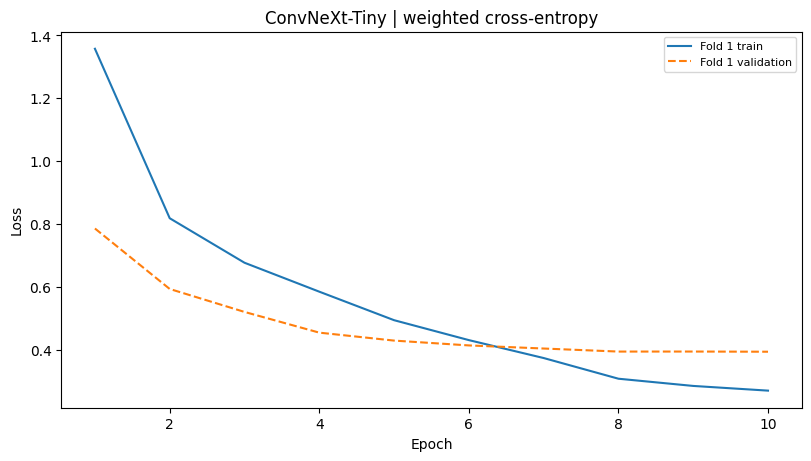

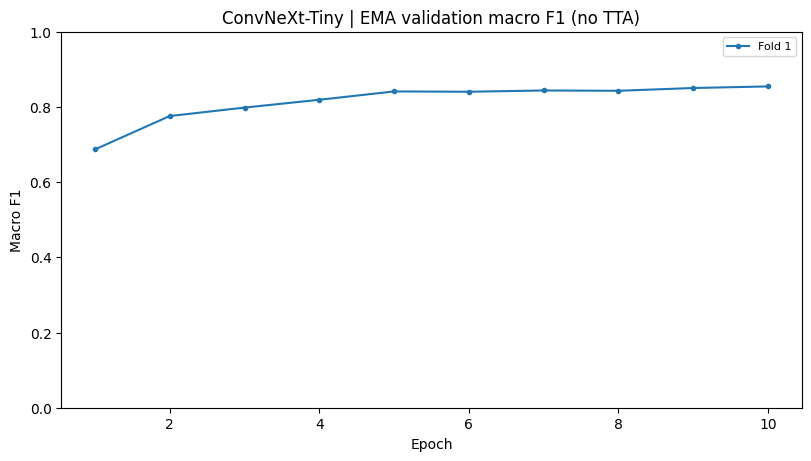

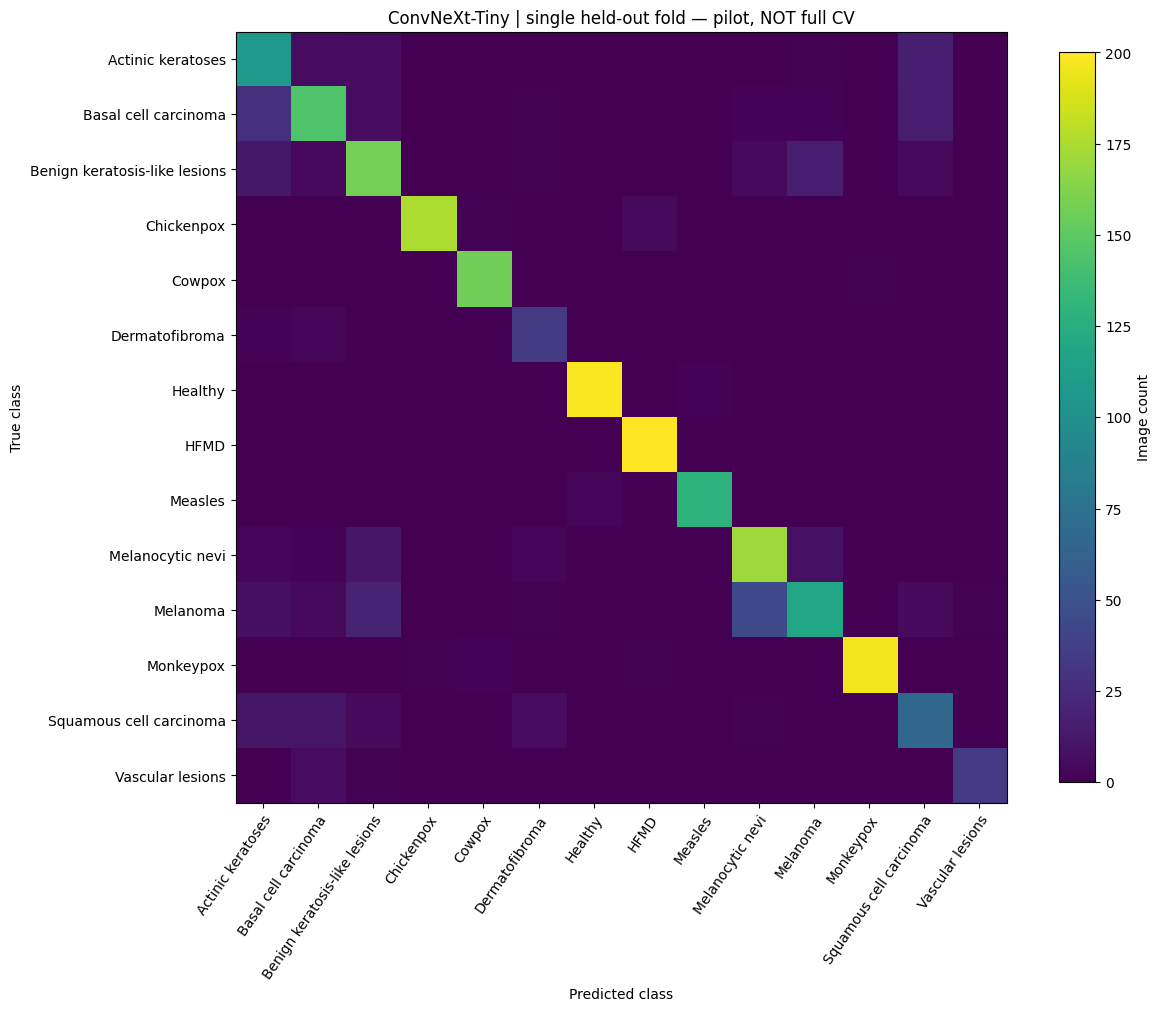

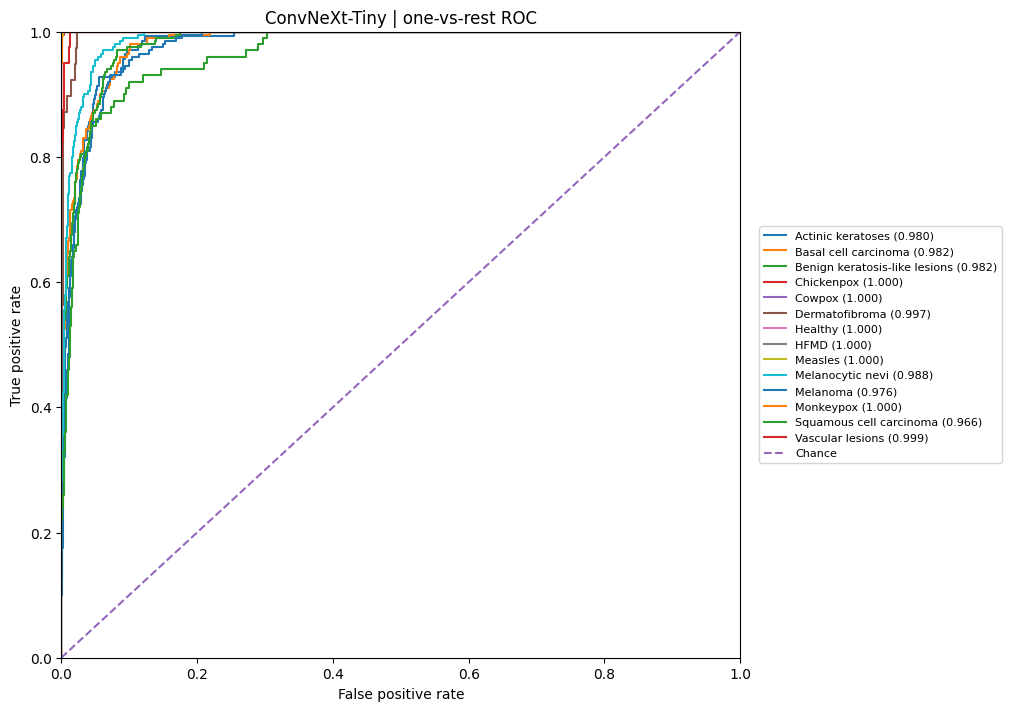

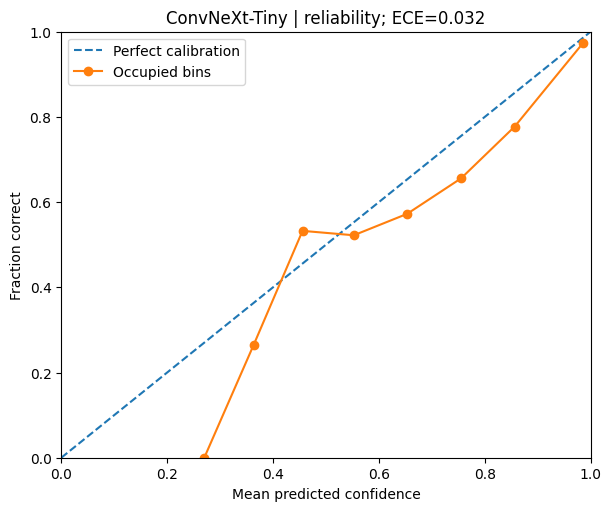


DenseNet-201 | densenet201.tv_in1k
Parameters with 14-class head: 18.120 M
Normalization: (0.485, 0.456, 0.406) (0.229, 0.224, 0.225) | output: /kaggle/working/skin_classifier/multimodel_fast_v2/densenet201
densenet201 | Fold 1/5, epoch 1/10 | batch 50/2188 | loss 2.5964 | 4.29 batch/s | RAM 2.58 GiB | free 15.29 GiB
densenet201 | Fold 1/5, epoch 1/10 | batch 100/2188 | loss 2.5043 | 4.54 batch/s | RAM 2.58 GiB | free 15.29 GiB
densenet201 | Fold 1/5, epoch 1/10 | batch 150/2188 | loss 2.4484 | 4.58 batch/s | RAM 2.58 GiB | free 15.28 GiB
densenet201 | Fold 1/5, epoch 1/10 | batch 200/2188 | loss 2.3790 | 4.64 batch/s | RAM 2.58 GiB | free 15.28 GiB
densenet201 | Fold 1/5, epoch 1/10 | batch 250/2188 | loss 2.3271 | 4.67 batch/s | RAM 2.58 GiB | free 15.28 GiB
densenet201 | Fold 1/5, epoch 1/10 | batch 300/2188 | loss 2.2554 | 4.66 batch/s | RAM 2.58 GiB | free 15.28 GiB
densenet201 | Fold 1/5, epoch 1/10 | batch 350/2188 | loss 2.2228 | 4.66 batch/s | RAM 2.58 GiB | free 15.28 GiB
de

,inference,accuracy,macro_f1,kappa,macro_auc_ovr,n_images,scope,model_key,model_name,parameters_millions,validation_used_for_epoch_selection
0,base,0.7761,0.7545,0.7571,0.9781,2188,"single held-out fold — pilot, NOT full CV",densenet201,densenet201.tv_in1k,18.1198,True


,precision,recall,f1-score,support
Actinic keratoses,0.4411,0.8345,0.5771,139.0000
Basal cell carcinoma,0.8065,0.5000,0.6173,200.0000
Benign keratosis-like lesions,0.7330,0.6450,0.6862,200.0000
Chickenpox,0.9467,0.8889,0.9169,180.0000
Cowpox,0.9804,0.9494,0.9646,158.0000
Dermatofibroma,0.4000,0.9231,0.5581,39.0000
Healthy,0.9268,0.9500,0.9383,200.0000
HFMD,0.9369,0.9650,0.9507,200.0000
Measles,0.9104,0.9242,0.9173,132.0000
Melanocytic nevi,0.6933,0.7800,0.7341,200.0000


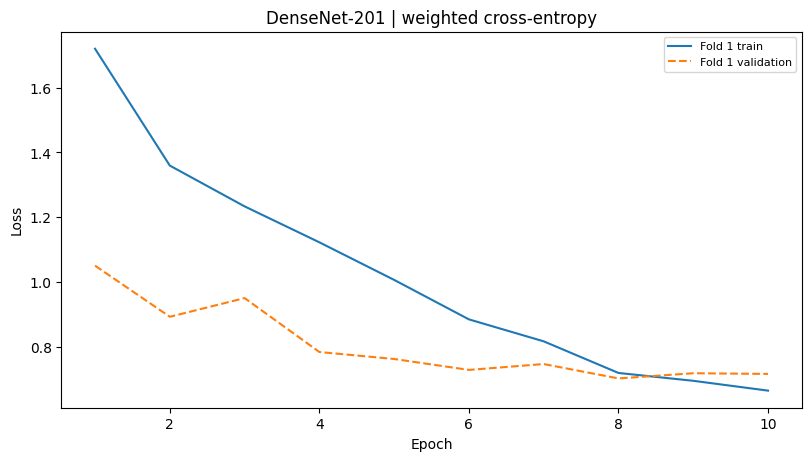

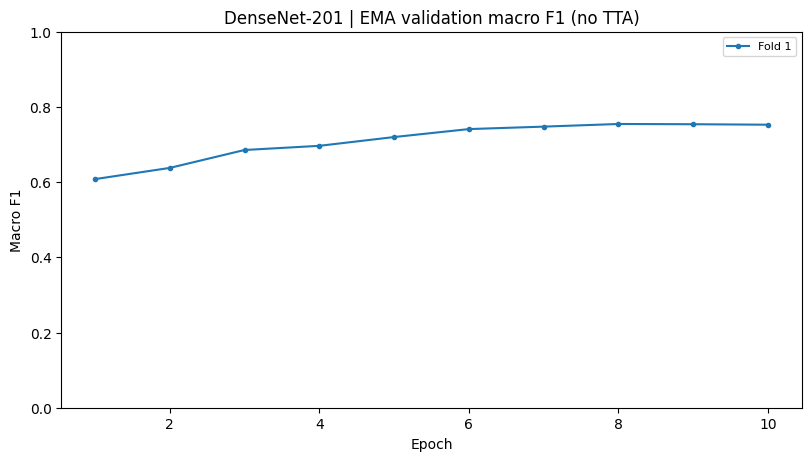

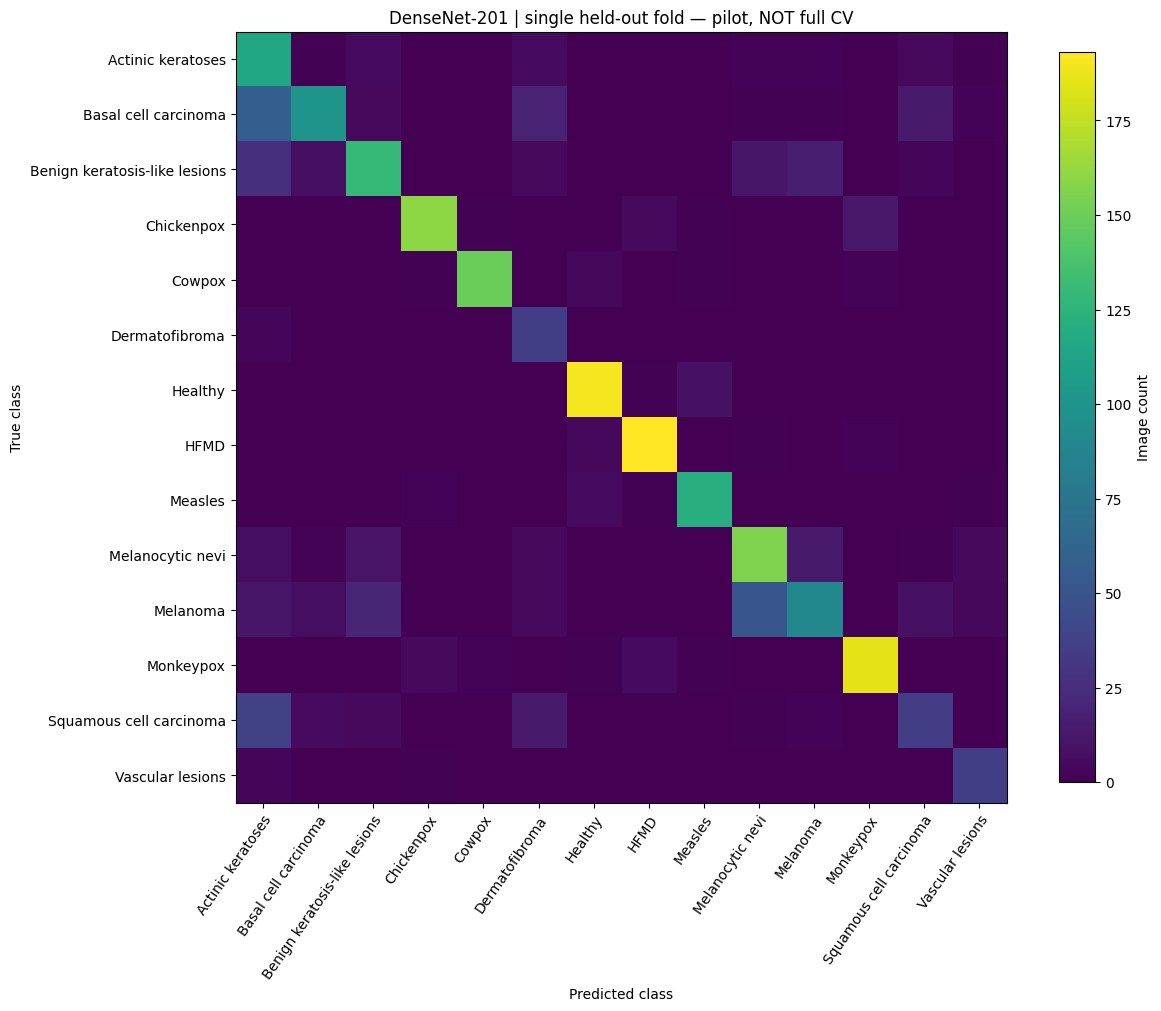

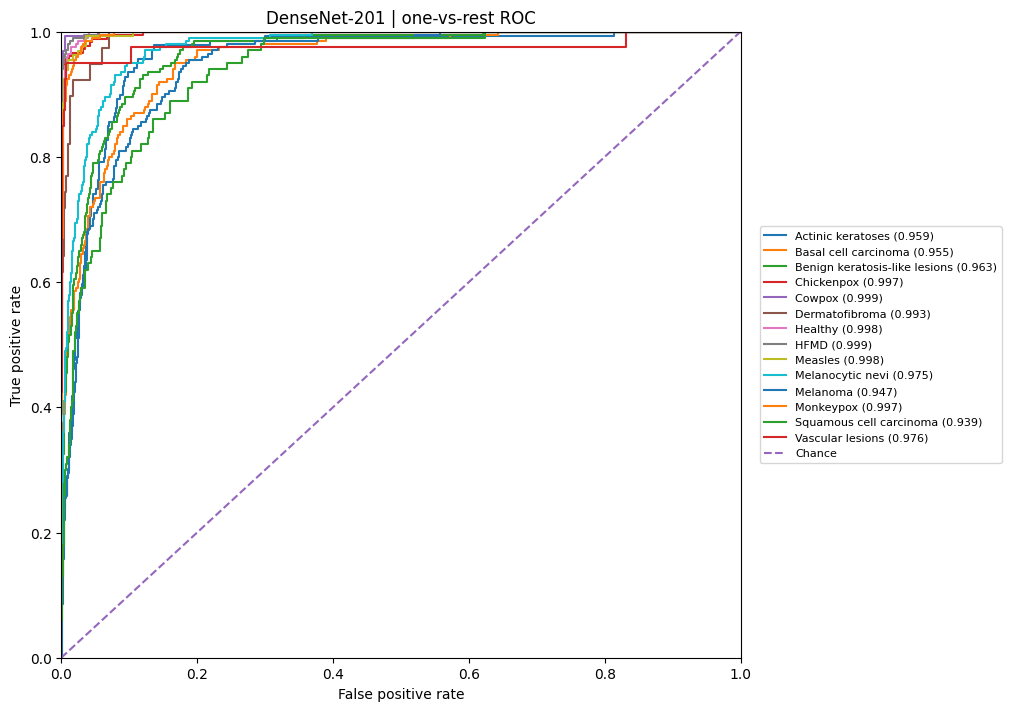

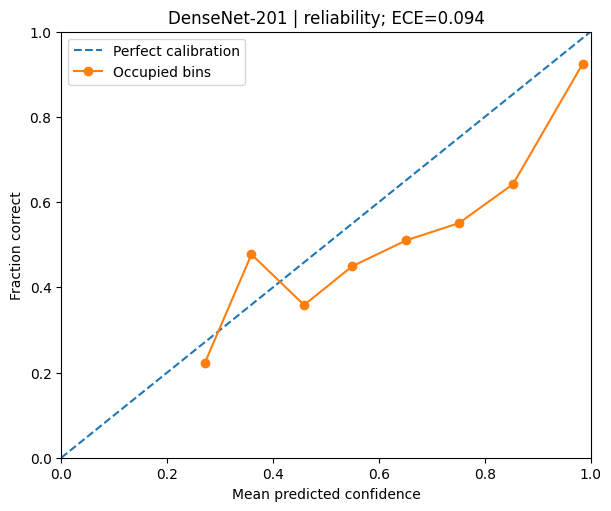


MobileNetV2 | mobilenetv2_100.ra_in1k
Parameters with 14-class head: 2.242 M
Normalization: (0.485, 0.456, 0.406) (0.229, 0.224, 0.225) | output: /kaggle/working/skin_classifier/multimodel_fast_v2/mobilenetv2_100
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 50/2188 | loss 3.4985 | 2.89 batch/s | RAM 2.66 GiB | free 12.12 GiB
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 100/2188 | loss 3.4124 | 4.27 batch/s | RAM 2.66 GiB | free 12.12 GiB
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 150/2188 | loss 3.4156 | 5.11 batch/s | RAM 2.66 GiB | free 12.12 GiB
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 200/2188 | loss 3.2618 | 5.67 batch/s | RAM 2.66 GiB | free 12.12 GiB
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 250/2188 | loss 3.1869 | 6.05 batch/s | RAM 2.66 GiB | free 12.12 GiB
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 300/2188 | loss 3.0940 | 6.34 batch/s | RAM 2.66 GiB | free 12.12 GiB
mobilenetv2_100 | Fold 1/5, epoch 1/10 | batch 350/2188 | loss 3.0255 | 6.56 batch/s 

In [ ]:
def run_single_model(model_key):
    configure_model_run(model_key)
    oof_base = np.full((len(df), NUM_CLASSES), np.nan, dtype=np.float32)
    oof_tta = np.full_like(oof_base, np.nan)
    all_history, checkpoint_paths = [], []
    for fold in RUN_FOLDS:
        indices, base_probs, tta_probs, history, checkpoint_path = train_fold(fold)
        oof_base[indices] = base_probs
        oof_tta[indices] = tta_probs
        all_history.extend(history)
        checkpoint_paths.append(checkpoint_path)
        # Persist completed folds so a later fold failure does not lose their predictions.
        np.savez_compressed(OUTPUT_DIR / "oof_probabilities.npz", base=oof_base, tta=oof_tta,
                            labels=df.label.to_numpy(), folds=df.fold.to_numpy())
    history_df = pd.DataFrame(all_history)
    history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
    print("Finished:", len(checkpoint_paths), "fold(s). Checkpoints:", checkpoint_paths)
    details = evaluate_and_export(oof_base, oof_tta, history_df)
    details["checkpoints"] = checkpoint_paths
    (OUTPUT_DIR / "model_complete.json").write_text(json.dumps(details, indent=2))
    cleanup()
    return details


def run_selected_models():
    results = {}
    for model_key in MODELS_TO_RUN:
        results[model_key] = run_single_model(model_key)
        (EXPERIMENT_DIR / "completed_model_paths.json").write_text(json.dumps(results, indent=2))
        cleanup()
    return results

model_results = run_selected_models()

## 14. Compare the models on the same validation images

In [ ]:
def compare_models(results):
    frames = [pd.read_csv(Path(details["output_dir"]) / "metrics.csv")
              for details in results.values()]
    comparison = pd.concat(frames, ignore_index=True)
    comparison = comparison.sort_values(["inference", "macro_f1"], ascending=[True, False])
    comparison.to_csv(EXPERIMENT_DIR / "model_comparison.csv", index=False)
    display(comparison.round(4))
    for inference, part in comparison.groupby("inference", sort=False):
        ordered = part.sort_values("macro_f1")
        names = [MODEL_REGISTRY[key]["display"] for key in ordered.model_key]
        fig, ax = plt.subplots(figsize=(8, max(4, len(ordered) * 0.7)), layout="constrained")
        bars = ax.barh(names, ordered.macro_f1)
        ax.bar_label(bars, fmt="%.3f", padding=3)
        ax.set(xlabel="Validation macro F1", xlim=(0, 1.08),
               title=f"Model comparison | {inference}\nValidation also used for epoch selection")
        stem = "model_comparison_base" if inference == "base" else "model_comparison_tta"
        save_plot(fig, EXPERIMENT_DIR, stem)
    return comparison

comparison_df = compare_models(model_results)

## 15. Generate explanations for the same validation-image sample

XAI uses each image's own held-out-fold checkpoint, not an ensemble containing models that trained
on that image. The same image sample is used across architectures. When `XAI_TARGET="predicted"`,
different models may explain different predicted classes; those targets are saved explicitly.
Use `XAI_TARGET="true"` to compare all models against the same ground-truth class.

This cell can be rerun after changing XAI settings without retraining. Existing images for matching
filenames are replaced; `selected_examples.csv` and `xai_summary.csv` identify the current selection.

In [ ]:
xai_tables = {}
if RUN_XAI:
    xai_examples = selected_xai_examples()
    display(xai_examples[["class_name", "fold", "path"]])
    for model_key, details in model_results.items():
        xai_tables[model_key] = run_xai_for_model(model_key, details["output_dir"], xai_examples)
    print("XAI complete. See each model folder's xai/ directory.")
else:
    print("XAI skipped because RUN_XAI=False.")

## 16. Predict a genuinely new image

The helper below loads one checkpoint at a time and uses **that checkpoint's own preprocessing**.
It supports a single architecture, fold averaging, or equal-weight averaging across architectures.
Do not evaluate a training/validation image with an ensemble whose other folds trained on it.
This helper is not called automatically; edit the commented examples after training.

In [ ]:
@torch.no_grad()
def predict_unseen_image(image_path, checkpoint_paths, use_tta=False):
    checkpoint_paths = list(checkpoint_paths)
    if not checkpoint_paths:
        raise ValueError("Supply at least one trained checkpoint path.")
    all_probabilities = []
    for path in checkpoint_paths:
        model, cfg = load_inference_model(path)
        try:
            with open_rgb(image_path) as rgb:
                inputs = move_inputs(checkpoint_transform(cfg)(rgb).unsqueeze(0))
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                logits = model(inputs)
            probabilities = logits.float().softmax(dim=1)
            if use_tta:
                with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                    flipped_logits = model(torch.flip(inputs, dims=[3]))
                probabilities = (probabilities + flipped_logits.float().softmax(dim=1)) / 2
            all_probabilities.append(probabilities.cpu().numpy()[0])
        finally:
            del model
            cleanup()
    mean_probabilities = np.mean(all_probabilities, axis=0)
    return pd.DataFrame({"class": CLASSES, "probability": mean_probabilities}).sort_values(
        "probability", ascending=False, ignore_index=True)

# Single architecture (one fold in fast mode; five folds in full mode):
# predict_unseen_image("/kaggle/input/independent-test/example.jpg",
#                      model_results["mobilenetv2_100"]["checkpoints"])

# Cross-model ensemble for INDEPENDENT / genuinely new images only:
# paths = [p for details in model_results.values() for p in details["checkpoints"]]
# predict_unseen_image("/kaggle/input/independent-test/example.jpg", paths, use_tta=True)

print("Experiment outputs:", EXPERIMENT_DIR.resolve())

## 17. Troubleshooting, research boundaries and references

**GPU memory:** try batch 2 / accumulation 32 / validation batch 2 and a new `RUN_TAG`.
Accumulation does not reproduce large-batch BatchNorm statistics. This notebook deliberately uses
one GPU and one architecture at a time. Do not start another training loop in another cell.

**Resuming:** keep the same data, settings and `RUN_TAG`. A runtime cannot recover a folder that
Kaggle has deleted. Preserve the whole experiment directory, not just `best_fold_0.pth`.
The large last-state checkpoint is deleted only after a fold completes when
`KEEP_LAST_CHECKPOINTS=False`. Completed-fold reuse still works from its best model and predictions.

**Pretrained weights:** the initial download needs Internet or a matching local ImageNet checkpoint
in `LOCAL_PRETRAINED_PATHS`. The updated classifiers have 14 outputs. Old EfficientNet fine-tuned
weights are not compatible with these architectures. Local initialization files must match the
registered model's original pretrained format; recovery files are a separate format.

**Model scale:** ConvNeXt-Tiny and DenseNet-201 are larger comparators, not mobile models simply
because one is called "Tiny". MobileNetV2 and DeiT-Tiny are the smaller default options. The optional
MobileViT-XXS hybrid is smaller again. Its reference pretrained input is 256 × 256; this experiment
intentionally fine-tunes/evaluates it at the same configured 224 × 224 size as the other models.

**Explanation limits:** a Grad-CAM map can legitimately be constant or all zero, particularly for
random/poorly trained models. The export flags this and omits the misleading colored overlay.
IG depends on the baseline and number of integration steps. Inspect the recorded completeness
residual and compare more steps/baselines for research use. No causal or clinical validity is claimed.

**Performance limits:** no accuracy, superiority, speedup, confidence interval or XAI-quality
claim is supplied by this code. The training hyperparameters are a shared starting point. An
independent test set, leakage checks and repeated seeds are needed for stronger comparisons.

### Implementation references
- [ConvNeXt-Tiny timm model card](https://huggingface.co/timm/convnext_tiny.fb_in1k)
- [DenseNet-201 timm model card](https://huggingface.co/timm/densenet201.tv_in1k)
- [MobileNetV2 timm model card](https://huggingface.co/timm/mobilenetv2_100.ra_in1k)
- [DeiT-Tiny timm model card](https://huggingface.co/timm/deit_tiny_patch16_224.fb_in1k)
- [Optional MobileViT-XXS model card](https://huggingface.co/timm/mobilevit_xxs.cvnets_in1k)
- [Grad-CAM for vision transformers: layer choice and reshaping](https://jacobgil.github.io/pytorch-gradcam-book/vision_transformers.html)
- [Grad-CAM, original paper](https://arxiv.org/abs/1610.02391)
- [Integrated Gradients, original paper](https://proceedings.mlr.press/v70/sundararajan17a.html)
- [PyTorch AMP examples, including gradient accumulation](https://docs.pytorch.org/docs/stable/notes/amp_examples.html)

### Validation status
See `VALIDATION.md` in the accompanying package for the precise checks performed and their limits.
The distributed notebook has empty result cells so software-test outputs cannot be mistaken for
performance on your real skin-image dataset. Run its preflight and `SMOKE_TEST=True` on your own GPU
before a larger experiment.